### Import packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import seaborn as sns 
from sklearn.metrics import mean_absolute_error,mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
pd.options.mode.chained_assignment = None
from rich.progress import track
import pickle

### Get the file with the recording that we want

In [2]:
folder_path = 'FelixData/'
dir_scalar = folder_path + "scalars_45056_0_sparse_PI_new.csv"
dir_hstates = folder_path + "hstates_45056_0_sparse_PI_new.csv"

### Merge files and get longest id dataFrame

In [3]:
def merge_files(file_path, file_path_scalar):

    df_scalar = pd.read_csv(file_path_scalar, low_memory=False)
    df_scalar = df_scalar[df_scalar['# action'] != '# action']
    #print(df_scalar.columns)
    #print("Len of scalar file", len(df_scalar))

    df = pd.read_csv(file_path, header=None, nrows=len(df_scalar))

    # Renaming the columns as "Node i"
    df.columns = [f"Node {i}" for i in range(1, df.shape[1] + 1)]
    #print("Len of hstates file", len(df))
    
    df_scalar = df_scalar[df_scalar['player_position_x'] != 'player_position_x']
    merged_df = pd.concat([df_scalar.reset_index(drop=True), df.reset_index(drop=True)], axis=1)

    return merged_df
df = merge_files(dir_hstates, dir_scalar)

def get_episode(df):
    most_common_episode_id = df['episode_id'].mode()[0]
    episode_df = df[df['episode_id'] == most_common_episode_id]
    episode_df['player_position_x'] = episode_df['player_position_x'].str.split('.').str[0].astype(int)
    episode_df['player_position_y'] = episode_df['player_position_y'].str.split('.').str[0].astype(int)
    episode_df['delta_x'] = episode_df['delta_x'].str.split('.').str[0].astype(int)
    episode_df['delta_y'] = episode_df['delta_y'].str.split('.').str[0].astype(int)
    return episode_df

episode_df = get_episode(df)

In [4]:
#range1 = np.arange(-800, -20, 10)
range1 = np.arange(-21, -20)
range2 = np.arange(-20, 20, 1)  # Note: the end is 21 to include 20
#range3 = np.arange(20, 801, 10)
range3 = np.arange(20,21)

# Combine the ranges
dt_list = np.concatenate((range1, range2, range3))

# Encode speed

In [5]:
def preprocess_speed(steps, df_merged):
    # Calculate MA
    df_merged['MA_x'] = df_merged['player_position_x'].rolling(window=10, center=True).mean()
    df_merged['MA_y'] = df_merged['player_position_y'].rolling(window=10, center=True).mean()
    df_merged = df_merged.dropna()
    df_merged['MA_x_speed'] = df_merged['MA_x'].diff()
    df_merged['MA_y_speed'] = df_merged['MA_y'].diff()
    df_merged = df_merged.dropna()
    # Remove rows with NaN values resulting from shift
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    #print(df_merged['delta_X'].unique())
    return df_merged

df_merged = preprocess_speed(7, episode_df)
print(len(episode_df))
print(len(df_merged))

17982
17965


In [6]:
def correlate_speed(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['MA_x_speed', 'MA_y_speed']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 

    # Linear regression model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    # Kernel
    model_kernel = Ridge(alpha=0.01)#KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    model_kernel.fit(X_train, y_train)

    
    return model1, model, X_test, y_test, model_kernel
a = correlate_speed(df_merged)

In [7]:
scores_linear = []
RMSE_linear = []
scores_ridge = []
RMSE_ridge = []
naive = []
scores_kernel = []
rmse_kernel = []
all_data = []
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
# store the models before running the code!!!!
for i in track(dt_list):
    df_merged = preprocess_speed(i, episode_df)
    model1, model, X_test, y_test, model_kernel = correlate_speed(df_merged)
    all_data.append([model1, model, model_kernel])
    scores_linear.append(model1.score(X_test, y_test))
    RMSE_linear.append(root_mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test)) )
    scores_ridge.append(model.score(X_test, y_test))
    RMSE_ridge.append(root_mean_squared_error(y_true=y_test,y_pred=model.predict(X_test)) )
    scores_kernel.append(model_kernel.score(X_test, y_test))
    rmse_kernel.append(root_mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test)) )
    naive.append(root_mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test)) )

Output()

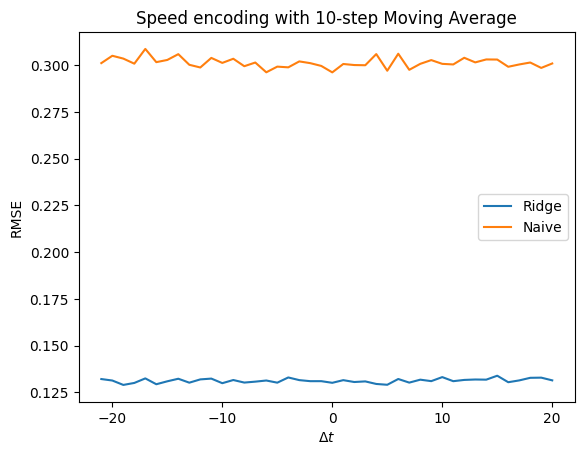

In [10]:
plt.figure(1)
#plt.plot(dt_list, np.array(RMSE_linear), label="Linear")
plt.plot(dt_list, np.array(RMSE_ridge), label="Ridge")
plt.plot(dt_list, np.array(naive), label="Naive")
#plt.plot(dt_list, np.array(rmse_kernel), label="Kernel")
plt.legend()
plt.title(r"Speed encoding with 10-step Moving Average")
plt.ylabel("RMSE")
plt.xlabel(r"$\Delta t$")
plt.show()

# Relative Displacement

### Preprosessing step for relative displacement

In [4]:
def preprocess(steps, df_merged):
    # Calculate delta values for future steps
    df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
    df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']
    # Remove rows with NaN values resulting from shift
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    #print(df_merged['delta_X'].unique())
    return df_merged

df_merged = preprocess(10, episode_df)

### Fitting models for relative displacement

In [5]:
def correlate(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['delta_X', 'delta_Y']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 

    # Linear regression model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    # Kernel
    model_kernel = Ridge(alpha=0.01)#KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    model_kernel.fit(X_train, y_train)

    
    return model1, model, X_test, y_test, model_kernel
a = correlate(df_merged)

### Finding RMSE and score of the different methods for relative displacement

In [4]:
range1 = np.arange(-520, -20, 100)
#range1 = np.arange(-21, -20)
range2 = np.arange(-20, 20, 5)  # Note: the end is 21 to include 20
range3 = np.arange(20, 521, 100)
#range3 = np.arange(20,21)

# Combine the ranges
dt_list = np.concatenate((range1, range2, range3))

In [7]:
scores_linear = []
RMSE_linear = []
scores_ridge = []
RMSE_ridge = []
naive = []
scores_kernel = []
rmse_kernel = []
all_data = []
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
# store the models before running the code!!!!
for i in track(dt_list):
    df_merged = preprocess(i, episode_df)
    model1, model, X_test, y_test, model_kernel = correlate(df_merged)
    all_data.append([model1, model, model_kernel])
    scores_linear.append(model1.score(X_test, y_test))
    RMSE_linear.append(root_mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test)) )
    scores_ridge.append(model.score(X_test, y_test))
    RMSE_ridge.append(root_mean_squared_error(y_true=y_test,y_pred=model.predict(X_test)) )
    scores_kernel.append(model_kernel.score(X_test, y_test))
    rmse_kernel.append(root_mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test)) )
    naive.append(root_mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test)) )

Output()

### Plot RMSE and score for relative displacement

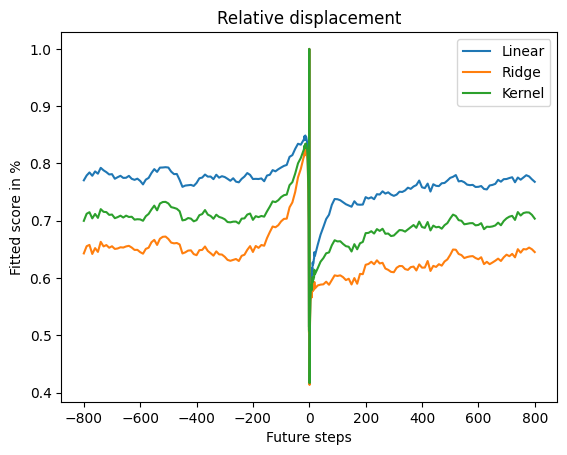

In [9]:
plt.figure(0)
plt.plot(dt_list, scores_linear, label= "Linear")
plt.plot(dt_list, scores_ridge, label="Ridge")
plt.plot(dt_list, scores_kernel, label="Kernel")
plt.legend()
plt.title("Relative displacement")
plt.ylabel("Fitted score in %")
plt.xlabel("Future steps")
plt.show()

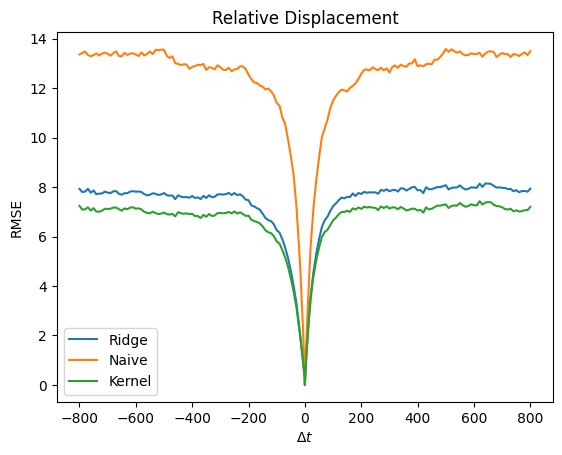

5.486560204111319
11.871432154696356


In [12]:
plt.figure(1)
#plt.plot(dt_list, np.array(RMSE_linear), label="Linear")
plt.plot(dt_list, np.array(RMSE_ridge), label="Ridge")
plt.plot(dt_list, np.array(naive), label="Naive")
plt.plot(dt_list, np.array(rmse_kernel), label="Kernel")
plt.legend()
plt.title("Relative Displacement")
plt.ylabel("RMSE")
plt.xlabel(r"$\Delta t$")
plt.show()
print(np.array(RMSE_linear)[68])
print(np.array(naive)[68])

### Store data from run in file

In [8]:
import pickle

# After running the for loop
data_to_store = {
    'scores_linear': scores_linear,
    'RMSE_linear': RMSE_linear,
    'scores_ridge': scores_ridge,
    'RMSE_ridge': RMSE_ridge,
    'naive': naive,
    'scores_kernel': scores_kernel,
    'rmse_kernel': rmse_kernel,
    'all_data': all_data
}

# Save the data to a file
with open('output/data_14336_800_r_nPI.pkl', 'wb') as f:
    pickle.dump(data_to_store, f)

### Get data back

In [55]:
with open('models_data_1.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Access the lists like this:
scores_linear = loaded_data['scores_linear']
RMSE_linear = loaded_data['RMSE_linear']
scores_ridge = loaded_data['scores_ridge']
RMSE_ridge = loaded_data['RMSE_ridge']
naive = loaded_data['naive']
scores_kernel = loaded_data['scores_kernel']
rmse_kernel = loaded_data['rmse_kernel']
print(rmse_kernel)
#all_data = loaded_data['all_data']

[5.613629258016383, 5.496459815517033, 5.486501670634484, 5.180598560624784, 5.107503959885889, 4.9189042612876115, 4.767006230161398, 4.580134659686058, 4.4188289698247445, 4.276887829792914, 4.360934837538907, 4.196674534340905, 3.8006505263761587, 3.7064291231703654, 3.307348576139127, 2.936098593503558, 2.732854134489798, 2.2796523707721885, 1.806646474049586, 1.240194666400997, 0.6049142309428708, 0.7180055846658526, 1.3481404207160264, 1.8853570187850734, 2.2224092463030742, 2.7724289172052528, 2.9838232831249627, 3.2090217991046703, 3.3604252688330565, 3.6692803448768334, 3.8876695499756484, 4.022012145245327, 4.228441380740754, 4.38685349836846, 4.707236944439996, 4.804628244649999, 4.7608493464369985, 4.8983858128545155, 5.224914017970621, 5.237376365828585, 5.289260755407166, 5.310706399534714]


# Displacement from origo

### Preprocess

In [5]:
def preprocess_true_distance(steps, df_merged):

    # Calculate delta values for future steps
    df_merged['delta_X_from_O'] = df_merged['delta_x'].shift(-steps) #- df_merged['player_position_x']
    df_merged['delta_Y_from_O'] = df_merged['delta_y'].shift(-steps)# - df_merged['player_position_y']
    # Remove rows with NaN values resulting from shift
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    #print(df_merged['delta_X_from_O'].unique())
    return df_merged

df_merged = preprocess_true_distance(10, episode_df)
print(len(df_merged))

17972


### Fit models

In [6]:
def custom_train_test_split(X, Y, test_size=0.25):
    # Finn alle unike episoder
    episodes = X['episode_id'].unique()
    
    X_train_list = []
    Y_train_list = []
    X_test_list = []
    Y_test_list = []
    
    for ep in episodes:
        # Filtrer data for denne episoden
        mask = X['episode_id'] == ep
        X_ep = X[mask]
        Y_ep = Y[mask]
        
        # Finn indeksen for splitt
        n = len(X_ep)
        split_idx = int(n * (1 - test_size))
        
        # Del opp i train og test
        X_train_list.append(X_ep.iloc[:split_idx])
        Y_train_list.append(Y_ep.iloc[:split_idx])
        
        X_test_list.append(X_ep.iloc[split_idx:])
        Y_test_list.append(Y_ep.iloc[split_idx:])
    
    # Slå sammen alle episoders train og test
    X_train = pd.concat(X_train_list, ignore_index=True)
    Y_train = pd.concat(Y_train_list, ignore_index=True)
    X_test = pd.concat(X_test_list, ignore_index=True)
    Y_test = pd.concat(Y_test_list, ignore_index=True)
    
    # Fjern episode_id kolonnen fra X og konverter til numpy
    X_train = X_train.drop(columns='episode_id').values
    X_test = X_test.drop(columns='episode_id').values
    
    # Konverter Y til numpy
    Y_train = Y_train.values
    Y_test = Y_test.values
    
    return X_train, X_test, Y_train, Y_test, 1, 1

In [7]:
def custom_bin_split(X, Y, n_bins=20, n_test_bins=5, random_state=None):
    # Optional: for reproducibility of the random selection
    if random_state is not None:
        np.random.seed(random_state)
    
    # Ensure X and Y have the same number of rows
    assert len(X) == len(Y), "X and Y must have the same number of samples."
    
    # Create bin indices: we can use np.array_split to split indices into n_bins parts
    indices = np.arange(len(X))
    bins = np.array_split(indices, n_bins)
    
    # Randomly choose test bins
    test_bins_idx = np.random.choice(np.arange(n_bins), size=n_test_bins, replace=False)
    test_bins_idx = set(test_bins_idx)
    
    # Select the test and train indices
    test_indices = np.concatenate([bins[i] for i in test_bins_idx])
    train_indices = np.concatenate([bins[i] for i in range(n_bins) if i not in test_bins_idx])
    
    # Slice X and Y based on train/test indices
    X_train = X.iloc[train_indices]
    Y_train = Y.iloc[train_indices]
    X_test = X.iloc[test_indices]
    Y_test = Y.iloc[test_indices]
    
    # Convert to numpy arrays
    X_train = X_train.values
    Y_train = Y_train.values
    X_test = X_test.values
    Y_test = Y_test.values
    
    return X_train, X_test, Y_train, Y_test, 1, 1

In [8]:
def correlate_from_O(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['delta_X_from_O', 'delta_Y_from_O']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]
    features1 = df_merged[[f'Node {i}' for i in range(1,513)] + ['episode_id']]

    current_pos = df_merged[['delta_x', 'delta_y']]
    current_pos_array = np.array(current_pos)

    X = np.array(features)
    Y = np.array(y)

    #X_train, X_test, y_train, y_test, current_pos_train, current_pos_test = train_test_split(X, Y,current_pos_array, test_size = 0.25, shuffle=True,random_state=42) 
    X_train, X_test, y_train, y_test, current_pos_train, current_pos_test = custom_train_test_split(features1, y)
    #X_train, X_test, y_train, y_test, current_pos_train, current_pos_test = custom_bin_split(features1, y)
    # Linear regression model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    # Kernel
    model_kernel = Ridge(alpha=0.01)# KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    model_kernel.fit(X_train, y_train)
    
    return model1, model, X_test, y_test, model_kernel, current_pos_test

mm1, mm, X_test1, y_test1, mm_ker, current_pos_test = correlate_from_O(df_merged)

### Step if finding model based on mutliple episodes: 

In [49]:
file_names_hstates = ['FelixData/hstates_34816_0_spi.csv', 'FelixData/hstates_36864_0_spi.csv', 'FelixData/hstates_38912_0_spi.csv', 'FelixData/hstates_40960_0_spi.csv', 'FelixData/hstates_43008_0_spi.csv', 'FelixData/hstates_45056_0_spi.csv']
file_names_scalars = ['FelixData/scalars_34816_0_spi.csv', 'FelixData/scalars_36864_0_spi.csv', 'FelixData/scalars_38912_0_spi.csv', 'FelixData/scalars_40960_0_spi.csv', 'FelixData/scalars_43008_0_spi.csv', 'FelixData/scalars_45056_0_spi.csv']
df_list = []
s = 0
for i in range(6):
    df = merge_files(file_names_hstates[i], file_names_scalars[i])
    print(i)
    while True:
        episode_df = get_episode(df)
        if len(episode_df) < 3000:
            break
        print("#")
        episode_df = episode_df[500:-500]
        s += len(episode_df)
        df_list.append(episode_df)
        
        # Fix: Use `.isin()` to filter out rows with matching `episode_id`
        df = df[~df['episode_id'].isin(episode_df['episode_id'].unique())]
        
        if len(df) < 3000:
            break

    #print()

print(s)
df_merged_list = []
print(len(df_list))
for j in range(len(df_list)):
    df_merged = preprocess_true_distance(0, df_list[j])
    df_merged_list.append(df_merged)
merged_df = pd.concat(df_merged_list, axis=0, ignore_index=True)
print(len(merged_df))
model1, model, X_test, y_test, model_kernel,current_pos_test = correlate_from_O(merged_df)
rrmse = root_mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test))
print(rrmse)
X_test_13_episodes = X_test

0
#
1
#
#
2
#
3
#
#
#
4
#
5
#
#
#
#
#
185879
13
185879
11.493587231692704


In [10]:
from scipy.stats import norm
#scores_linear = []
#RMSE_linear = []
#scores_ridge = []
#RMSE_ridge = []
naive = []
#scores_kernel = []
rmse_kernel = []
all_data = []
#rmse_kernel_ci = []  # To store 95% CIs
ci = []
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
# store the models before running the code!!!!
for i in track(dt_list):
    print(i)
    df_merged_list = []
    for j in range(13):
        #print(j)
        df_merged = preprocess_true_distance(i, df_list[j])
        df_merged_list.append(df_merged)
    merged_df = pd.concat(df_merged_list, axis=0, ignore_index=True)
    model1, model, X_test, y_test, model_kernel,_ = correlate_from_O(merged_df)
    all_data.append([model_kernel])
    # Bootstrapping for 95% CI
    #n_bootstrap = 1000
    #bootstrap_rmse = []
    #for _ in range(n_bootstrap):
    #    indices = np.random.choice(len(y_test), size=len(y_test), replace=True)
    #    bootstrap_rmse.append(root_mean_squared_error(y_true=y_test[indices], y_pred=model_kernel.predict(X_test)[indices]))
    
    # Calculate 95% CI
    #lower_bound = np.percentile(bootstrap_rmse, 2.5)
    #upper_bound = np.percentile(bootstrap_rmse, 97.5)
    #rmse_kernel_ci.append((lower_bound, upper_bound))
    #analysis(model1, model, X_test, y_test)
    #cores_linear.append(model1.score(X_test, y_test))
    #RMSE_linear.append(root_mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test)) )
    #scores_ridge.append(model.score(X_test, y_test))
    #RMSE_ridge.append(root_mean_squared_error(y_true=y_test,y_pred=model.predict(X_test)) )
    #scores_kernel.append(model_kernel.score(X_test, y_test))
    rmse_kernel.append(root_mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test)) )


    # Compute standard error of RMSE
    predictions = model_kernel.predict(X_test)
    
    # Compute RMSE
    errors = y_test - predictions
    squared_errors = errors ** 2
    rmse = np.sqrt(np.mean(squared_errors))
    se = np.sqrt(np.var(squared_errors, ddof=1) / len(y_test))
    
    # 95% CI
    z = norm.ppf(0.975)  # 1.96 for 95% CI
    lower_bound = rmse - z * se
    upper_bound = rmse + z * se
    ci.append((lower_bound, upper_bound))


    naive.append(root_mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test)) )



Output()

-520

-420

-320

-220

...

120

220

320

420

520

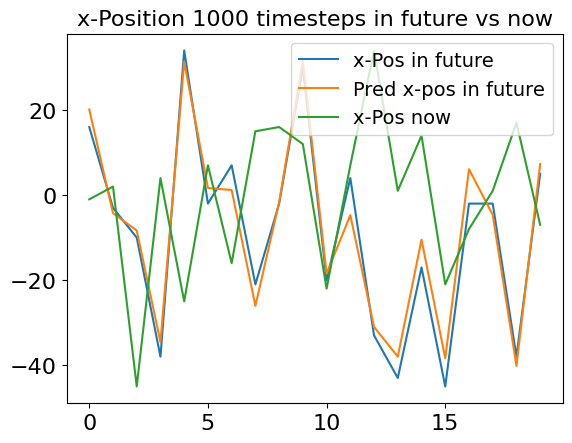

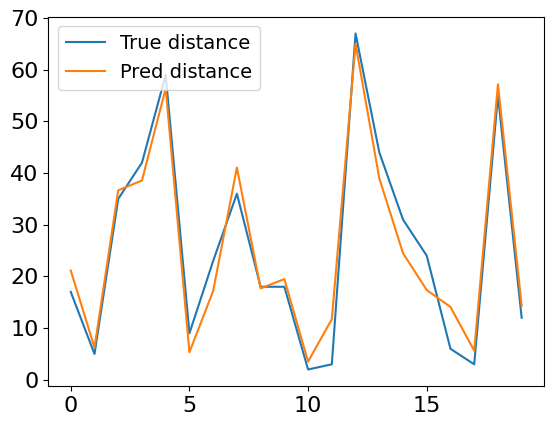

Total pred magnitude: 19.25513445781317
Total now-pos magnitude: 19.679406130268198
Total actual future magnitude: 19.897174329501915

Total predicted distance traveled: 27.958843398336256
Total actual distance traveled: 28.410871647509577
5.522727926448947
5.811171584365938
Fraction of matching signs: 0.4050287356321839


In [53]:
#n = root_mean_squared_error(y_true=y_test1,y_pred=np.zeros_like(y_test1))
#rm = root_mean_squared_error(y_true=y_test1,y_pred=mm1.predict(X_test1))
#print(rm)

pred_future = model.predict(X_test)
true_future = y_test
true_now = current_pos_test
true_distance = true_future - true_now
pred_distance = pred_future - true_now
#print(y_test1)
#print(np.std(mm1.predict(X_test1) - y_test1))
#print(y_test1[:10,0])
#print(mm1.predict(X_test1)[:10,0])
#print(current_pos_test[:10,0])
W = model.coef_
b = model.intercept_

# Compute predictions using matrix multiplication
predictions = X_test @ W.T + b.T
plt.figure(0)
plt.title("x-Position 1000 timesteps in future vs now")
plt.plot(y_test[:20,0], label="x-Pos in future")
plt.plot(model.predict(X_test)[:20,0], label="Pred x-pos in future")
#plt.plot(predictions[:20,0], label="Prediction")
plt.plot(current_pos_test[:20,0], label="x-Pos now")
plt.legend()
plt.show()
plt.figure(1)
plt.plot(np.abs(true_distance[:20,0]), label="True distance")
plt.plot(np.abs(pred_distance[:20,0]), label="Pred distance")
plt.legend()
plt.show()
print(f'Total pred magnitude: {np.mean(np.abs(model.predict(X_test)[:,1]))}')
print(f'Total now-pos magnitude: {np.mean(np.abs(current_pos_test[:,1]))}')
print(f'Total actual future magnitude: {np.mean(np.abs(y_test[:,1]))}')
print()
print(f'Total predicted distance traveled: {np.mean(np.abs(pred_distance[:,1]))}')
print(f'Total actual distance traveled: {np.mean(np.abs(true_distance[:,1]))}')
rmse = np.sqrt(np.mean((true_future[:,1] - pred_future[:,1]) ** 2))
print(rmse)
rmse = np.sqrt(np.mean((true_future[:,0] - pred_future[:,0]) ** 2))
print(rmse)

matches = np.sign(true_future[:, 0]) == np.sign(true_now[:, 0])
match_fraction = np.sum(matches) / len(matches)

print("Fraction of matching signs:", match_fraction)

### Store RMSE and score of model fittings

In [12]:
scores_linear = []
RMSE_linear = []
scores_ridge = []
RMSE_ridge = []
naive = []
scores_kernel = []
rmse_kernel = []
all_data = []
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
# store the models before running the code!!!!
for i in track(dt_list):
    df_merged = preprocess_true_distance(i, episode_df)
    model1, model, X_test, y_test, model_kernel,_ = correlate_from_O(df_merged)
    all_data.append([model1, model, model_kernel])
    #analysis(model1, model, X_test, y_test)
    scores_linear.append(model1.score(X_test, y_test))
    RMSE_linear.append(root_mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test)) )
    scores_ridge.append(model.score(X_test, y_test))
    RMSE_ridge.append(root_mean_squared_error(y_true=y_test,y_pred=model.predict(X_test)) )
    scores_kernel.append(model_kernel.score(X_test, y_test))
    rmse_kernel.append(root_mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test)) )
    naive.append(root_mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test)) )

Output()

### Plot

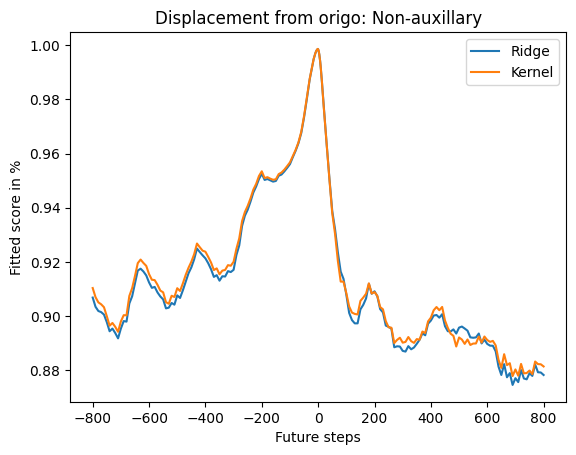

In [13]:
plt.figure(0)
plt.title("Displacement from origo: Non-auxillary")
#plt.plot(dt_list, scores_linear, label= "Linear")
plt.plot(dt_list, scores_ridge, label="Ridge")
plt.plot(dt_list, scores_kernel, label="Kernel")
plt.legend()
plt.ylabel("Fitted score in %")
plt.xlabel("Future steps")
plt.show()

/var/folders/jt/df2_lrn955n11nzch1rzc5qw0000gn/T/ipykernel_37635/2571772449.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')  # Choose a clean style


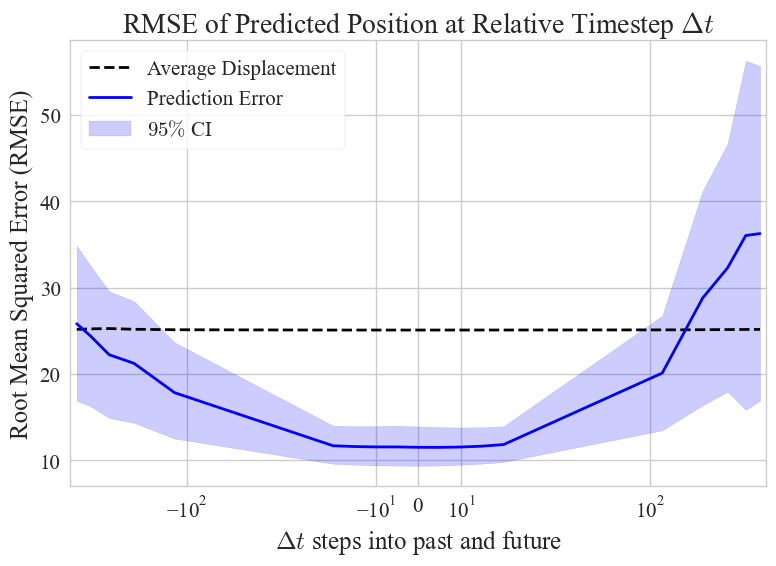

In [48]:
plt.style.use('seaborn-whitegrid')  # Choose a clean style
from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'

plt.figure(1)
plt.title(r"RMSE of Predicted Position at Relative Timestep $\Delta t$", fontsize=20)

# Plot the lines with adjusted linewidths and colors
plt.plot(dt_list, np.array(naive), label="Average Displacement", color="black", linewidth=2, linestyle="--")
plt.plot(dt_list, np.array(rmse_kernel), label="Prediction Error", color="blue", linewidth=2)

rmse_l = [i[0] for i in ci]
rmse_u = [i[1] for i in ci]

# Add confidence interval shading
plt.fill_between(dt_list, rmse_l, rmse_u, color='blue', alpha=0.2, label=r"$95\%$ CI")

# Add labels, legend, and adjust tick labels
plt.ylabel("Root Mean Squared Error (RMSE)", fontsize=18)
plt.xlabel(r"$\Delta t$ steps into past and future", fontsize=18)
plt.legend(loc='upper left', fontsize=15, frameon=True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xscale("symlog", linthresh=40)

# Display the plot
plt.show()


In [10]:
import scienceplots
rmse_l = [i[0] for i in ci]
rmse_u = [i[1] for i in ci]

# Set style and figure size
plt.style.use('science')  # Use a clean style
plt.figure(figsize=(8, 6))          # Set figure size

# Title and axis labels
plt.title("Displacement from Origin - 13 Episodes No-Shuffle Split", fontsize=18)
plt.xlabel("Future Steps", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

# Plot data
plt.plot(dt_list, naive, label="Naive", color="orange", linestyle='--', linewidth=1)
plt.plot(dt_list, rmse_kernel, label="Ridge", color="blue", linestyle='-', linewidth=1)

# Fill between for confidence interval
plt.fill_between(dt_list, rmse_l, rmse_u, color='blue', alpha=0.2, label="95% CI")

# Add legend
plt.legend(fontsize=10, loc='upper left', frameon=True)

# Improve layout
#plt.tight_layout()

# Save as high-resolution file (useful for conferences)
#plt.savefig("conference_plot.png", dpi=300)

# Show the plot
plt.show()


RuntimeError: latex was not able to process the following string:
b'lp'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error ../45b35e7c45bf1f94c12d11a2e5717b88.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(../45b35e7c45bf1f94c12d11a2e5717b88.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-22>
(/Users/fb/Library/TinyTeX/texmf-dist/tex/latex/base/article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(/Users/fb/Library/TinyTeX/texmf-dist/tex/latex/base/size10.clo))

! LaTeX Error: File `type1cm.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.7 \usepackage
               {type1ec}^^M
No pages of output.
Transcript written on 45b35e7c45bf1f94c12d11a2e5717b88.log.




<Figure size 800x600 with 1 Axes>

In [13]:
import pickle
# After running the for loop
data_to_store = {
    #'scores_linear': scores_linear,
    #'RMSE_linear': RMSE_linear,
    #'scores_ridge': scores_ridge,
    #'RMSE_ridge': RMSE_ridge,
    'naive': naive,
    #'scores_kernel': scores_kernel,
    'rmse_kernel': rmse_kernel,
    'all_data': all_data,
    'ci': ci
}

# Save the data to a file
with open('output/data_40k_13_520_a_spi_ci_extrapolation.pkl', 'wb') as f:
    pickle.dump(data_to_store, f)

# Code to look at PCA

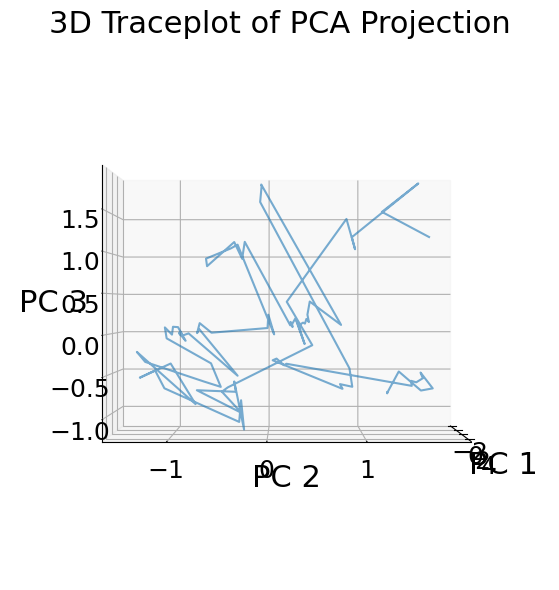

Effective Dimensionality: 88
Cosines of Principal Angles: [0.99948875 0.99815726 0.99710324 0.99645327 0.99595482 0.99523975
 0.99323893 0.99186177 0.99054947 0.98979246 0.98725128 0.9851482
 0.98345201 0.97964501 0.97635182 0.96975901 0.96768372 0.96572167
 0.96101979 0.95321674 0.95209327 0.93756373 0.91928315 0.90769169
 0.8850614  0.87482863 0.85671941 0.84131129 0.80641917 0.73907299
 0.70866652 0.64184916 0.49270268 0.41342863 0.30821255 0.24368114
 0.18661007 0.09112627 0.02343298]


In [35]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract features from df_merged
fig = plt.figure(figsize=(10, 7))
for i in range(1):
    features = df_list[i][[f'Node {i}' for i in range(1, 513)]][:100].values

    # Perform PCA to reduce to 3 dimensions
    pca = PCA(n_components=3)
    projected_data = pca.fit_transform(features)

    # Create a 3D traceplot
    
    ax = fig.add_subplot(111, projection='3d')

    # Plot the trace
    ax.plot(projected_data[:, 0], projected_data[:, 1], projected_data[:, 2], alpha=0.6)#marker='o'
    # Set camera angle
    ax.view_init(elev=0, azim=0)  # Change elev and azim to adjust the camera

# Add axis labels
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('3D Traceplot of PCA Projection')

# Show the plot
plt.show()

# Assuming `data` is your (T x 512) time series matrix
pca = PCA()
pca.fit(df_list[2][[f'Node {i}' for i in range(1, 513)]][:1000].values)

# Explained variance ratios
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Find effective dimensionality at 95% explained variance
effective_dimension = np.argmax(explained_variance_ratio >= 0.999) + 1
print(f"Effective Dimensionality: {effective_dimension}")

from scipy.linalg import svd

# Assume data1 and data2 are (T x 512) matrices for the two datasets
k = 39  # Effective dimension

# Perform PCA for both datasets
pca1 = PCA(n_components=k).fit(df_list[0][[f'Node {i}' for i in range(1, 513)]][:1000].values)
pca2 = PCA(n_components=k).fit(df_list[1][[f'Node {i}' for i in range(1, 513)]][:1000].values)

# Get the top k principal components (each as a matrix of size 512 x k)
subspace1 = pca1.components_.T  # Shape (512, k)
subspace2 = pca2.components_.T  # Shape (512, k)

# Compute the principal angles via SVD
_, sigma, _ = svd(subspace1.T @ subspace2)  # Singular values correspond to cosines of principal angles

print("Cosines of Principal Angles:", sigma)


# Code to find out long term prediction "error"

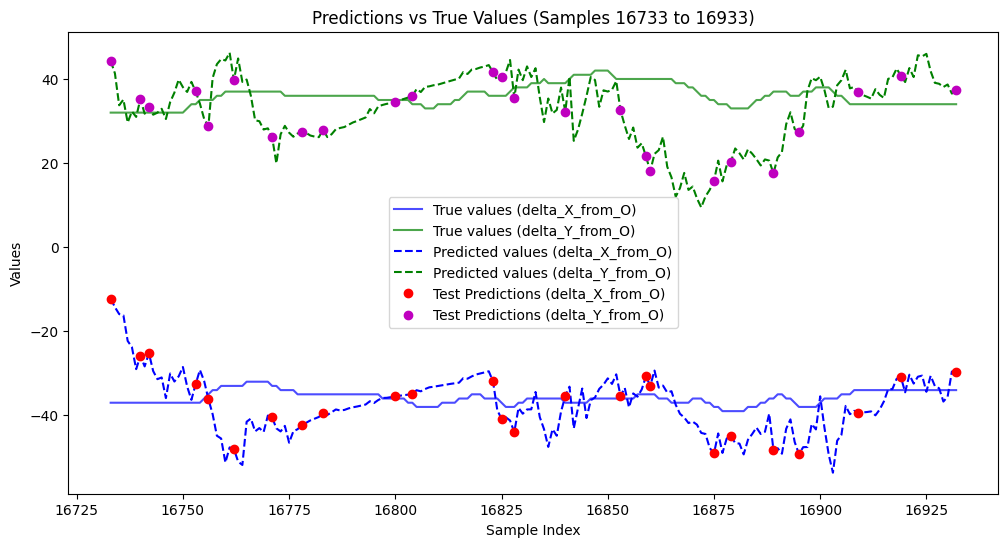

In [38]:
def correlate_from_O_test(df_merged):
    # Your existing code...
    y = df_merged[['delta_X_from_O', 'delta_Y_from_O']]
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]
    current_pos = df_merged[['delta_x', 'delta_y']]

    X = np.array(features)
    Y = np.array(y)
    current_pos_array = np.array(current_pos)

    # Generate indices
    indices = np.arange(X.shape[0])

    # Split data and indices
    X_train, X_test, y_train, y_test, current_pos_train, current_pos_test, idx_train, idx_test = train_test_split(
        X, Y, current_pos_array, indices, test_size=0.1, shuffle=True, random_state=42
    )

    # Train models
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    model_kernel = Ridge(alpha=0.01)
    model_kernel.fit(X_train, y_train)

    # Return indices and training data
    return model1, model, X_test, y_test, model_kernel, current_pos_test, X_train, y_train, idx_train, idx_test
df_merged = preprocess_true_distance(500, episode_df)
mm1, mm, X_test1, y_test1, mm_ker, current_pos_test, X_train1, y_train1, idx_train, idx_test = correlate_from_O_test(df_merged)
# Predict using the trained Ridge regression model
# Predictions
y_pred_train = mm.predict(X_train1)
y_pred_test = mm.predict(X_test1)

n_samples = df_merged.shape[0]
n_outputs = y_train1.shape[1]

# Initialize arrays
y_pred_total = np.zeros((n_samples, n_outputs))
y_total = np.zeros((n_samples, n_outputs))

# Fill predictions and true values in the original order
y_pred_total[idx_train] = y_pred_train
y_pred_total[idx_test] = y_pred_test

y_total[idx_train] = y_train1
y_total[idx_test] = y_test1

# Visualization parameters
start_vis = len(idx_train)+1000  # Starting index for visualization
num_vis = 200     # Number of samples to visualize

# Define the range of indices you're plotting
plot_indices = np.arange(start_vis, start_vis + num_vis)

# Find test indices within the specified range
test_indices_in_plot = np.intersect1d(idx_test, plot_indices)

# Predicted values at test indices within the plotting range
y_pred_test_in_plot_X = y_pred_total[test_indices_in_plot, 0]
y_pred_test_in_plot_Y = y_pred_total[test_indices_in_plot, 1]

# Plotting
plt.figure(figsize=(12, 6))

# Plot true values
plt.plot(plot_indices, y_total[start_vis:start_vis + num_vis, 0], label='True values (delta_X_from_O)', color='blue', alpha=0.7)
plt.plot(plot_indices, y_total[start_vis:start_vis + num_vis, 1], label='True values (delta_Y_from_O)', color='green', alpha=0.7)

# Plot predicted values as lines
plt.plot(plot_indices, y_pred_total[start_vis:start_vis + num_vis, 0], label='Predicted values (delta_X_from_O)', color='blue', linestyle='--')
plt.plot(plot_indices, y_pred_total[start_vis:start_vis + num_vis, 1], label='Predicted values (delta_Y_from_O)', color='green', linestyle='--')

# Overlay markers at test indices for delta_X_from_O
plt.plot(test_indices_in_plot, y_pred_test_in_plot_X, 'ro', label='Test Predictions (delta_X_from_O)', markersize=6)

# Overlay markers at test indices for delta_Y_from_O
plt.plot(test_indices_in_plot, y_pred_test_in_plot_Y, 'mo', label='Test Predictions (delta_Y_from_O)', markersize=6)

plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Values')
plt.title(f'Predictions vs True Values (Samples {start_vis} to {start_vis + num_vis})')
plt.show()



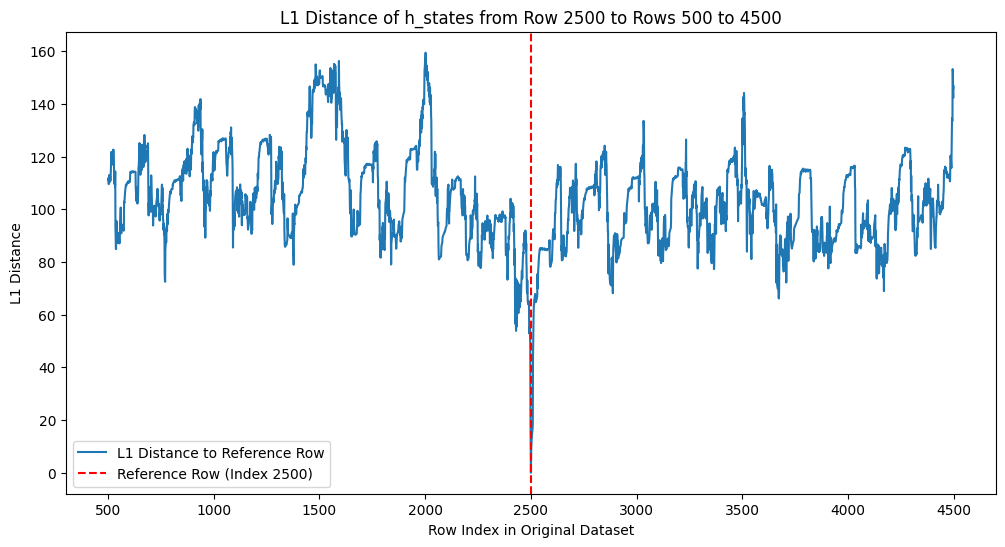

In [35]:
# Reference row index in the original dataset
original_row_idx = 2500

# Check if the index is within bounds
if original_row_idx >= X_train1.shape[0]:
    print(f"Row index {original_row_idx} is out of bounds for X with shape {X_train1.shape}")
else:
    # Extract the reference row
    x_ref = X_train1[original_row_idx]
    
    # Compute L1 distances to all other rows in X
    window_size = 2000  # Number of samples before and after the reference index
    start_idx = max(0, original_row_idx - window_size)
    end_idx = min(X_train1.shape[0], original_row_idx + window_size)

    # Slice the distances and indices
    distances = np.sum(np.abs(X_train1 - x_ref), axis=1)
    indices = np.arange(start_idx, end_idx)
    distances_window = distances[start_idx:end_idx]

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(indices, distances_window, label='L1 Distance to Reference Row')
    plt.axvline(x=original_row_idx, color='red', linestyle='--', label=f'Reference Row (Index {original_row_idx})')
    plt.xlabel('Row Index in Original Dataset')
    plt.ylabel('L1 Distance')
    plt.title(f'L1 Distance of h_states from Row {original_row_idx} to Rows {start_idx} to {end_idx}')
    plt.legend()
    plt.show()


# Angle decoding

### Preprosess data for angles

In [13]:
def preprocess_theta(steps, df_merged):
    # Calculate delta values for future steps
    df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
    df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']
    # Remove rows with NaN values resulting from shift

    # Calculate the angle θ using atan2
    df_merged['theta'] = np.arctan2(df_merged['delta_Y'], df_merged['delta_X'])

    # Calculate cosine and sine of the angle θ
    df_merged['cos_theta'] = np.cos(df_merged['theta'])
    df_merged['sin_theta'] = np.sin(df_merged['theta'])

    # Drop the temporary 'theta' column if not needed
    df_merged.drop(columns=['theta'], inplace=True)

    #print(df_merged[['delta_X', 'delta_Y', 'cos_theta', 'sin_theta']].head())

    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    #print(df_merged['delta_X'].unique())
    return df_merged

df_merged = preprocess_theta(10, episode_df)

In [14]:
def correlate_theta(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['cos_theta', 'sin_theta']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)
    #Y = Y / np.max(Y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 

    # Linear regression model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    # Kernel
    model_kernel = Ridge(alpha=0.01)#KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    model_kernel.fit(X_train, y_train)

    
    return model1, model, X_test, y_test, model_kernel

m1, m, X_test, y_test, mk = correlate_theta(df_merged)


In [15]:
def RMSE_angle(y_test, y_pred):
    """
    Calculate the Root Mean Square Error (RMSE) of angle predictions.
    """
    # Extract cosine and sine components for predictions
    cos_theta_pred = y_pred[:, 0]
    sin_theta_pred = y_pred[:, 1]
    
    # Extract cosine and sine components for real values
    cos_theta_real = y_test[:, 0]
    sin_theta_real = y_test[:, 1]
    
    # Compute cosine of the angle difference
    cos_diff = cos_theta_pred * cos_theta_real + sin_theta_pred * sin_theta_real
    
    # Clip the cosine values to the valid range [-1, 1] to avoid numerical issues
    cos_diff = np.clip(cos_diff, -1.0, 1.0)
    
    # Calculate the angle difference in radians
    theta_diff = np.arccos(cos_diff)
    
    # Square the angle differences
    squared_diff = theta_diff ** 2
    
    # Sum all squared differences
    sum_squared = np.sum(squared_diff)/len(squared_diff)
    
    # Compute the RMSE
    rmse = np.sqrt(sum_squared)

    rmse = np.degrees(rmse)
    
    return rmse

In [16]:
scores_linear = []
RMSE_linear = []
scores_ridge = []
RMSE_ridge = []
naive = []
scores_kernel = []
rmse_kernel = []
all_data = []
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
# store the models before running the code!!!!
for i in track(dt_list):
    df_merged = preprocess_theta(i, episode_df)
    model1, model, X_test, y_test, model_kernel = correlate_theta(df_merged)
    all_data.append([model1, model, model_kernel])
    scores_linear.append(model1.score(X_test, y_test))
    RMSE_linear.append(RMSE_angle(y_test,model1.predict(X_test)))
    RMSE_ridge.append(RMSE_angle(y_test,model.predict(X_test)))
    rmse_kernel.append(RMSE_angle(y_test,model_kernel.predict(X_test)))
    naive.append(RMSE_angle(y_test,np.zeros_like(y_test)))
    #RMSE_linear.append(root_mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test), multioutput='raw_values') )
    scores_ridge.append(model.score(X_test, y_test))
    #RMSE_ridge.append(root_mean_squared_error(y_true=y_test,y_pred=model.predict(X_test), multioutput='raw_values') )
    scores_kernel.append(model_kernel.score(X_test, y_test))
    #rmse_kernel.append(root_mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test), multioutput='raw_values') )
    #naive.append(root_mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test), multioutput='raw_values') )

Output()

### Plot

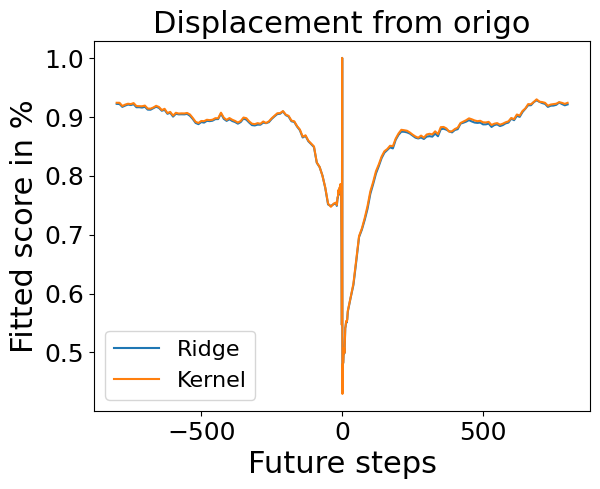

In [332]:
plt.figure(0)
plt.title("Displacement from origo")
#plt.plot(dt_list, scores_linear, label= "Linear")
plt.plot(dt_list, scores_ridge, label="Ridge")
plt.plot(dt_list, scores_kernel, label="Kernel")
plt.legend()
plt.ylabel("Fitted score in %")
plt.xlabel("Future steps")
plt.show()

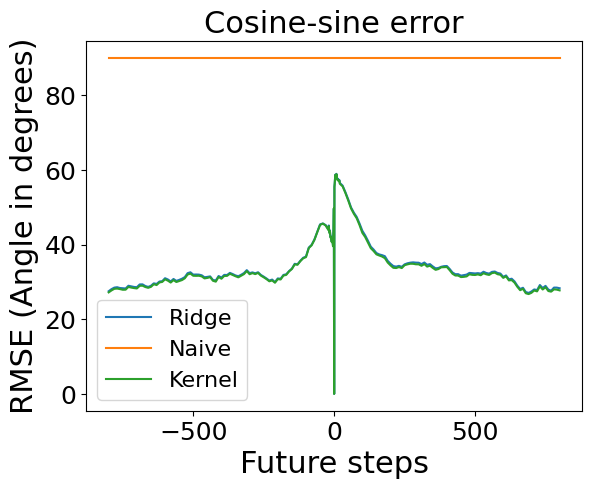

In [333]:
plt.figure(1)
plt.title("Cosine-sine error")
#plt.plot(dt_list, np.array(RMSE_linear)/np.array(naive), label="Linear")
plt.plot(dt_list, np.array(RMSE_ridge), label="Ridge")
plt.plot(dt_list, np.array(naive), label="Naive")
plt.plot(dt_list, np.array(rmse_kernel), label="Kernel")
plt.legend()
plt.ylabel("RMSE (Angle in degrees)")
plt.xlabel("Future steps")
plt.show()

In [17]:
data_to_store = {
    'scores_linear': scores_linear,
    'RMSE_linear': RMSE_linear,
    'scores_ridge': scores_ridge,
    'RMSE_ridge': RMSE_ridge,
    'naive': naive,
    'scores_kernel': scores_kernel,
    'rmse_kernel': rmse_kernel,
    'all_data': all_data
}

# Save the data to a file
with open('output/data_14336_800_t_nPI.pkl', 'wb') as f:
    pickle.dump(data_to_store, f)

### Plot files together

/var/folders/jt/df2_lrn955n11nzch1rzc5qw0000gn/T/ipykernel_15494/1737786181.py:43: RuntimeWarning: invalid value encountered in divide
  axs[i].plot(dt_list, np.array(data_list_14336[i]['rmse_kernel'])/np.array(data_list_14336[i]['naive']), label='Non-auxillary', color='blue')
/var/folders/jt/df2_lrn955n11nzch1rzc5qw0000gn/T/ipykernel_15494/1737786181.py:47: RuntimeWarning: invalid value encountered in divide
  axs[i].plot(dt_list, np.array(data_list_10240[i]['rmse_kernel'])/np.array(data_list_10240[i]['naive']), label='Auxillary', color='red', linestyle='--')


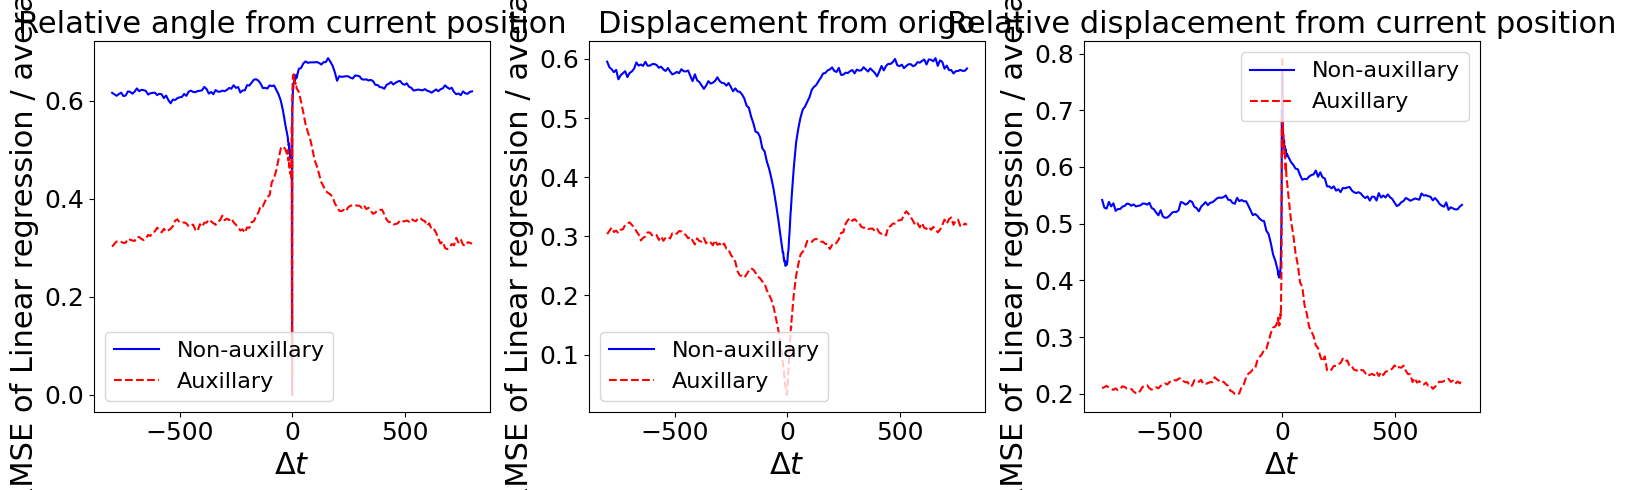

In [94]:
# File names for 14336 and 10240 data
import os
file_names_14336 = ['data_14336_800_t_nPI.pkl', 'data_14336_800_a_nPI.pkl', 'data_14336_800_r_nPI.pkl']
file_names_10240 = ['data_14336_800_t_PI.pkl', 'data_14336_800_a_PI.pkl', 'data_14336_800_r_PI.pkl']

# Initialize lists to store data
data_list_14336 = []
data_list_10240 = []

# Load the data for 14336 files
for file in file_names_14336:
    file_path = os.path.join("output", file)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        data_list_14336.append(data)

# Load the data for 10240 files
for file in file_names_10240:
    file_path = os.path.join("output", file)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        data_list_10240.append(data)

range1 = np.arange(-800, -20, 10)
range2 = np.arange(-20, 20, 1)  # Note: the end is 21 to include 20
range3 = np.arange(20, 801, 10)

# Combine the ranges
dt_list = np.concatenate((range1, range2, range3))

# Assuming dt_list is common or adjust for each file if different
# For simplicity, assuming a shared dt_list for both sets of data

# Create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Titles for each subplot
titles = ['Relative angle from current position', 'Displacement from origo', 'Relative displacement from current position']

# Loop through the data and plot RMSE_linear and naive for each pair of files
for i in range(3):
    # Plot for 14336 data
    axs[i].plot(dt_list, np.array(data_list_14336[i]['rmse_kernel'])/np.array(data_list_14336[i]['naive']), label='Non-auxillary', color='blue')
    #axs[i].plot(dt_list, data_list_14336[i]['naive'], label='naive_14336', color='green')
    
    # Plot for 10240 data
    axs[i].plot(dt_list, np.array(data_list_10240[i]['rmse_kernel'])/np.array(data_list_10240[i]['naive']), label='Auxillary', color='red', linestyle='--')
    #axs[i].plot(dt_list, data_list_10240[i]['naive'], label='naive_10240', color='orange', linestyle='--')
    
    # Set title, labels, and legend
    axs[i].set_title(titles[i])
    axs[i].set_xlabel(r'$\Delta t$')
    axs[i].set_ylabel('RMSE of Linear regression / average ')
    axs[i].legend()

    # Set x-axis to symlog scale
    #axs[i].set_xscale('symlog', linthresh=1)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

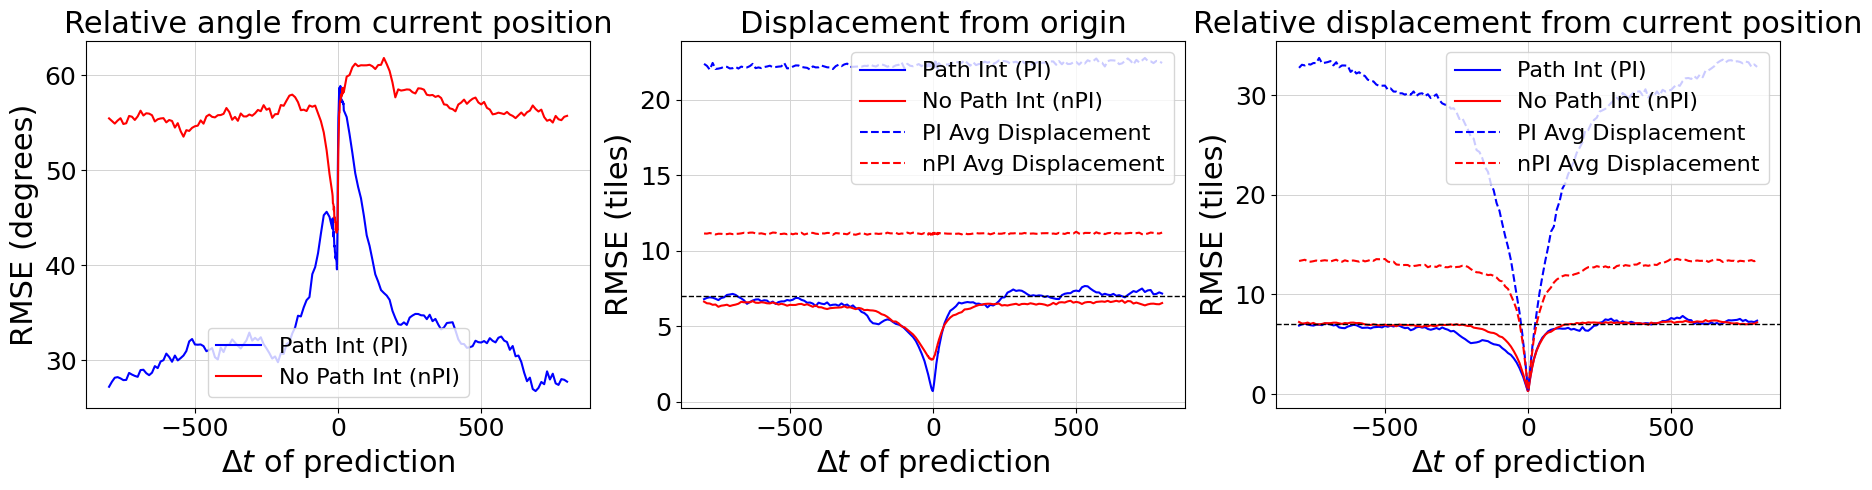

In [15]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# File names for 14336 and 10240 data
file_names_14336 = ['data_14336_800_t_nPI.pkl', 'data_14336_800_a_nPI.pkl', 'data_14336_800_r_nPI.pkl']
file_names_10240 = ['data_14336_800_t_PI.pkl', 'data_14336_800_a_PI.pkl', 'data_14336_800_r_PI.pkl']

# Initialize lists to store data
data_list_14336 = []
data_list_10240 = []

# Load the data for 14336 files
for file in file_names_14336:
    file_path = os.path.join("output", file)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        data_list_14336.append(data)

# Load the data for 10240 files
for file in file_names_10240:
    file_path = os.path.join("output", file)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        data_list_10240.append(data)


# Remove the value 0 from dt_list and corresponding entries in the data arrays
non_zero_indices = dt_list != 0  # This creates a boolean mask

# Apply the mask to dt_list and the relevant data arrays
dt_list_filtered = dt_list[non_zero_indices]
plt.rcParams.update({
    'axes.labelsize': 22,   # Size of x and y labels
    'xtick.labelsize': 18,  # Size of x-tick labels
    'ytick.labelsize': 18,  # Size of y-tick labels
    'legend.fontsize': 16,  # Size of legend font
    'axes.titlesize': 22    # Size of title
})
# Create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

x_label = ["RMSE (degrees)", "RMSE (tiles)", "RMSE (tiles)"]
grid_lines = np.arange(-500, 501, 50)
# Titles for each subplot
titles = ['Relative angle from current position', 'Displacement from origin', 'Relative displacement from current position']

# Loop through the data and plot RMSE_linear and naive for each pair of files
for i in range(3):
    if i == 2:
    # Apply the non-zero filter to the RMSE_linear and naive arrays
        rmse_linear_14336 = np.array(data_list_14336[i]['rmse_kernel'])[non_zero_indices]
        naive_14336 = np.array(data_list_14336[i]['naive'])[non_zero_indices]
        rmse_linear_10240 = np.array(data_list_10240[i]['rmse_kernel'])[non_zero_indices]
        naive_10240 = np.array(data_list_10240[i]['naive'])[non_zero_indices]
        #axs[i].plot(dt_list_filtered, rmse_linear_14336 / naive_14336, label='Non-auxillary', color='blue')
        
        axs[i].plot(dt_list_filtered, rmse_linear_10240 , label='Path Int (PI)', color='blue')
        axs[i].plot(dt_list_filtered, rmse_linear_14336, label='No Path Int (nPI)', color='red')
    
        # Plot for 10240 data
        #axs[i].plot(dt_list_filtered, rmse_linear_10240 / naive_10240, label='Auxillary', color='red', linestyle='--')
        
        axs[i].plot(dt_list_filtered, naive_10240, label='PI Avg Displacement', color='blue', linestyle='--')
        axs[i].plot(dt_list_filtered, naive_14336, label='nPI Avg Displacement', color='red', linestyle="--")
        axs[i].axhline(y=7, color='black', linestyle='--', linewidth=1)
    if i == 1:
        rmse_linear_14336 = np.array(data_list_14336[i]['rmse_kernel'])
        naive_14336 = np.array(data_list_14336[i]['naive'])
        rmse_linear_10240 = np.array(data_list_10240[i]['rmse_kernel'])
        naive_10240 = np.array(data_list_10240[i]['naive'])
        #axs[i].plot(dt_list, rmse_linear_14336 / naive_14336, label='Non-auxillary', color='blue')
        axs[i].plot(dt_list, rmse_linear_10240 , label='Path Int (PI)', color='blue')
        
        axs[i].plot(dt_list, rmse_linear_14336, label='No Path Int (nPI)', color='red')
    
    # Plot for 10240 data
        #axs[i].plot(dt_list, rmse_linear_10240 / naive_10240, label='Auxillary', color='red', linestyle='--')
        
        axs[i].plot(dt_list, naive_10240, label='PI Avg Displacement', color='blue', linestyle='--')
        axs[i].plot(dt_list, naive_14336, label='nPI Avg Displacement', color='red', linestyle="--")
        axs[i].axhline(y=7, color='black', linestyle='--', linewidth=1)

    if i == 0:
        rmse_linear_14336 = np.array(data_list_14336[i]['rmse_kernel'])[non_zero_indices]
        rmse_linear_10240 = np.array(data_list_10240[i]['rmse_kernel'])[non_zero_indices]
        axs[i].plot(dt_list_filtered, rmse_linear_10240 , label='Path Int (PI)', color='blue')
        axs[i].plot(dt_list_filtered, rmse_linear_14336, label='No Path Int (nPI)', color='red')
        
    
        # Plot for 10240 data
        #axs[i].plot(dt_list_filtered, rmse_linear_10240 / naive_10240, label='Auxillary', color='red', linestyle='--')
        

    
    # Add vertical grid lines every 100 units
    #axs[i].set_xticks(grid_lines)
    #axs[i].grid(True, which='both', axis='x', linestyle='--', linewidth=0.7)
    
    
    # Set title, labels, and legend
    axs[i].set_title(titles[i])
    axs[i].set_xlabel(r'$\Delta t$ of prediction')
    axs[i].set_ylabel(x_label[i])
    axs[i].legend()
    axs[i].grid(True, which="both", ls="-", linewidth = 0.7,color='lightgray')

    # Set x-axis to symlog scale
    #axs[i].set_xscale('symlog') #, linthresh=20
    #axs[i].set_yscale('log')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


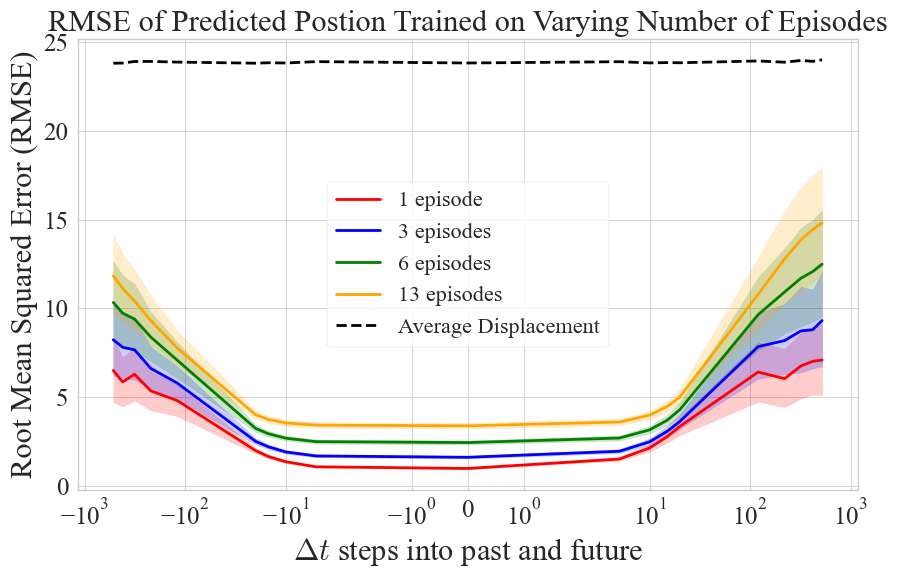

In [43]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

# Filenames for the two datasets
file_name_1 = 'data_40k_1_520_a_spi_ci.pkl'  # Replace with your first filename
file_name_2 = 'data_40k_3_520_a_spi_ci.pkl'   # Replace with your second filename
file_name_3 = 'data_40k_6_520_a_spi_ci.pkl'
file_name_4 = 'data_40k_13_520_a_spi_ci.pkl'
#file_name_3 = 'data_14336_800_a_PI.pkl'

# Load the data from the first file
file_path_1 = os.path.join("output", file_name_1)
with open(file_path_1, 'rb') as f:
    data_1 = pickle.load(f)

# Load the data from the second file
file_path_2 = os.path.join("output", file_name_2)
with open(file_path_2, 'rb') as f:
    data_2 = pickle.load(f)

# Load the data from the second file
file_path_3 = os.path.join("output", file_name_3)
with open(file_path_3, 'rb') as f:
    data_3 = pickle.load(f)


file_path_4 = os.path.join("output", file_name_4)
with open(file_path_4, 'rb') as f:
    data_4 = pickle.load(f)

# Remove zero entries from dt_list and corresponding data
non_zero_indices = dt_list != 0
#dt_list_filtered = dt_list[non_zero_indices]

# Extract and filter the required data arrays
rmse_linear_1 = np.array(data_1['rmse_kernel'])#[non_zero_indices]
naive_1 = np.array(data_1['naive'])#[non_zero_indices]
ci_1 = data_1['ci']
#print(non_zero_indices)
rmse_linear_2 = np.array(data_2['rmse_kernel'])#[non_zero_indices]
naive_2 = np.array(data_2['naive'])#[non_zero_indices]
ci_2 = data_2['ci']
rmse_linear_3 = np.array(data_3['rmse_kernel'])#[non_zero_indices]
naive_3 = np.array(data_3['naive'])#[non_zero_indices]
ci_3 = data_3['ci']

rmse_linear_4 = np.array(data_4['rmse_kernel'])#[non_zero_indices]
naive_4 = np.array(data_4['naive'])#[non_zero_indices]
ci_4 = data_4['ci']

rmse_l_1 = [i[0] for i in ci_1]
rmse_u_1 = [i[1] for i in ci_1]
rmse_l_2 = [i[0] for i in ci_2]
rmse_u_2 = [i[1] for i in ci_2]
rmse_l_3 = [i[0] for i in ci_3]
rmse_u_3 = [i[1] for i in ci_3]
rmse_l_4 = [i[0] for i in ci_4]
rmse_u_4 = [i[1] for i in ci_4]

# Set plotting parameters
plt.rcParams.update({
    'axes.labelsize': 22,   # Size of x and y labels
    'xtick.labelsize': 18,  # Size of x-tick labels
    'ytick.labelsize': 18,  # Size of y-tick labels
    'legend.fontsize': 16,  # Size of legend font
    'axes.titlesize': 22    # Size of title
})

# Create the plot
fig, ax = plt.subplots(figsize=(9, 6))

# Plot RMSE_linear data
ax.plot(dt_list, rmse_linear_1, label='1 episode', color='red')
ax.plot(dt_list, rmse_linear_2, label='3 episodes', color='blue')
ax.plot(dt_list, rmse_linear_3, label='6 episodes', color='green')
ax.plot(dt_list, rmse_linear_4, label='13 episodes', color='orange')
#ax.plot(dt_list_filtered, rmse_linear_3, label='PI', color='green')

# Plot naive data
#ax.plot(dt_list, naive_2, label='Naive 3 episodes', color='blue', linestyle='--')
#ax.plot(dt_list, naive_1, label='Naive 1 episode', color='red', linestyle='--')
#ax.plot(dt_list, naive_3, label='Naive 6 episodes', color='green', linestyle='--')
ax.plot(dt_list, naive_4, label='Average Displacement', color='black', linestyle='--')
#ax.plot(dt_list_filtered, naive_3, label='Naive PI', color='green', linestyle='--')


ax.fill_between(dt_list, rmse_l_1, rmse_u_1, color='red', alpha=0.2)
ax.fill_between(dt_list, rmse_l_2, rmse_u_2, color='blue', alpha=0.2)
ax.fill_between(dt_list, rmse_l_3, rmse_u_3, color='green', alpha=0.2)
ax.fill_between(dt_list, rmse_l_4, rmse_u_4, color='orange', alpha=0.2)

# Add a horizontal line at y=7
#ax.axhline(y=7, color='black', linestyle='--', linewidth=1)

# Set labels, title, and legend
ax.set_xlabel(r'$\Delta t$ steps into past and future')
ax.set_ylabel('Root Mean Squared Error (RMSE)')
ax.set_title(r'RMSE of Predicted Postion Trained on Varying Number of Episodes')
ax.legend(frameon=True)
ax.grid(True, which="both", ls="-", linewidth=0.7, color='lightgray')
ax.set_xscale('symlog')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


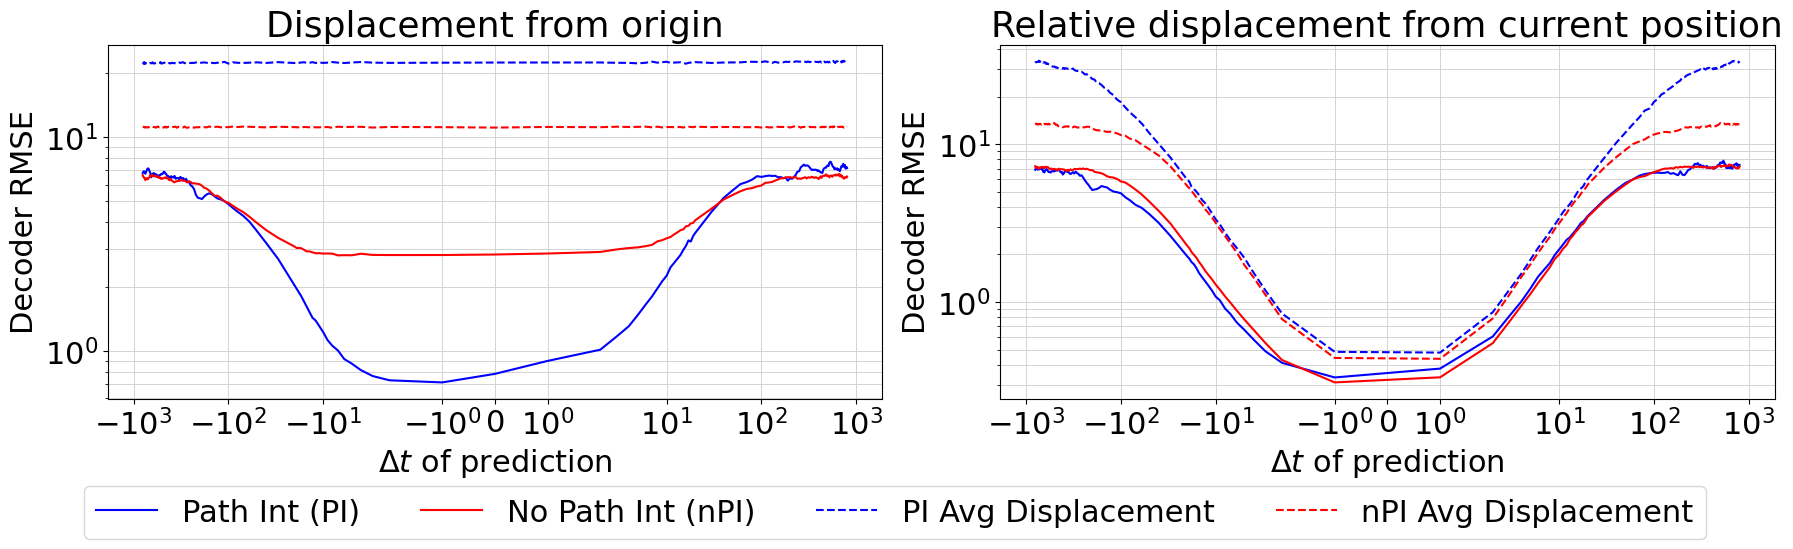

In [152]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# File names for 14336 and 10240 data
file_names_14336 = ['data_14336_800_t_nPI.pkl', 'data_14336_800_a_nPI.pkl', 'data_14336_800_r_nPI.pkl']
file_names_10240 = ['data_14336_800_t_PI.pkl', 'data_14336_800_a_PI.pkl', 'data_14336_800_r_PI.pkl']

# Initialize lists to store data
data_list_14336 = []
data_list_10240 = []

# Load the data for 14336 files
for file in file_names_14336:
    file_path = os.path.join("output", file)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        data_list_14336.append(data)

# Load the data for 10240 files
for file in file_names_10240:
    file_path = os.path.join("output", file)
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
        data_list_10240.append(data)


# Remove the value 0 from dt_list and corresponding entries in the data arrays
non_zero_indices = dt_list != 0  # This creates a boolean mask

# Apply the mask to dt_list and the relevant data arrays
dt_list_filtered = dt_list[non_zero_indices]
plt.rcParams.update({
    'axes.labelsize': 22,   # Size of x and y labels
    'xtick.labelsize': 22,  # Size of x-tick labels
    'ytick.labelsize': 22,  # Size of y-tick labels
    'legend.fontsize': 22,  # Size of legend font
    'axes.titlesize': 26    # Size of title
})
# Create subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

x_label = ["Decoder RMSE", "Decoder RMSE"]
grid_lines = np.arange(-500, 501, 50)
# Titles for each subplot
titles = ['Displacement from origin','Relative displacement from current position']

# Loop through the data and plot RMSE_linear and naive for each pair of files
for i in range(1,3):
    if i == 2:
    # Apply the non-zero filter to the RMSE_linear and naive arrays
        rmse_linear_14336 = np.array(data_list_14336[i]['rmse_kernel'])[non_zero_indices]
        naive_14336 = np.array(data_list_14336[i]['naive'])[non_zero_indices]
        rmse_linear_10240 = np.array(data_list_10240[i]['rmse_kernel'])[non_zero_indices]
        naive_10240 = np.array(data_list_10240[i]['naive'])[non_zero_indices]
        #axs[i].plot(dt_list_filtered, rmse_linear_14336 / naive_14336, label='Non-auxillary', color='blue')
        
        axs[i-1].plot(dt_list_filtered, rmse_linear_10240 , label='Path Int (PI)', color='blue')
        axs[i-1].plot(dt_list_filtered, rmse_linear_14336, label='No Path Int (nPI)', color='red')
    
        # Plot for 10240 data
        #axs[i].plot(dt_list_filtered, rmse_linear_10240 / naive_10240, label='Auxillary', color='red', linestyle='--')
        
        axs[i-1].plot(dt_list_filtered, naive_10240, label='PI Avg Displacement', color='blue', linestyle='--')
        axs[i-1].plot(dt_list_filtered, naive_14336, label='nPI Avg Displacement', color='red', linestyle="--")
    if i == 1:
        rmse_linear_14336 = np.array(data_list_14336[i]['rmse_kernel'])
        naive_14336 = np.array(data_list_14336[i]['naive'])
        rmse_linear_10240 = np.array(data_list_10240[i]['rmse_kernel'])
        naive_10240 = np.array(data_list_10240[i]['naive'])
        #axs[i].plot(dt_list, rmse_linear_14336 / naive_14336, label='Non-auxillary', color='blue')
        axs[i-1].plot(dt_list, rmse_linear_10240 , label='Path Int (PI)', color='blue')
        
        axs[i-1].plot(dt_list, rmse_linear_14336, label='No Path Int (nPI)', color='red')
    
    # Plot for 10240 data
        #axs[i].plot(dt_list, rmse_linear_10240 / naive_10240, label='Auxillary', color='red', linestyle='--')
        
        axs[i-1].plot(dt_list, naive_10240, label='PI Avg Displacement', color='blue', linestyle='--')
        axs[i-1].plot(dt_list, naive_14336, label='nPI Avg Displacement', color='red', linestyle="--")

        # Plot for 10240 data
        #axs[i].plot(dt_list_filtered, rmse_linear_10240 / naive_10240, label='Auxillary', color='red', linestyle='--')
        

    
    # Add vertical grid lines every 100 units
    #axs[i].set_xticks(grid_lines)
    #axs[i].grid(True, which='both', axis='x', linestyle='--', linewidth=0.7)
    
    
    # Set title, labels, and legend
    axs[i-1].set_title(titles[i-1])
    axs[i-1].set_xlabel(r'$\Delta t$ of prediction')
    axs[i-1].set_ylabel(x_label[i-1])
    axs[i-1].grid(True, which="both", ls="-", linewidth = 0.7,color='lightgray')

    # Set x-axis to symlog scale
    axs[i-1].set_xscale('symlog') #, linthresh=20
    axs[i-1].set_yscale('log')

handles, labels = axs[0].get_legend_handles_labels()  # Get the handles and labels from one of the subplots
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12))  # Place legend below the subplots

# Adjust layout and show plot
plt.tight_layout()
plt.show()

### Classification angle

In [1]:

def preprocess_theta_class(steps, df_merged):
    # Calculate delta values for future steps
    df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
    df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']
    
    # Remove rows with NaN values resulting from shift
    df_merged = df_merged.dropna(subset=['delta_X', 'delta_Y'])
    
    # Calculate the angle θ using atan2
    df_merged['theta'] = np.arctan2(df_merged['delta_Y'], df_merged['delta_X'])
    
    # Normalize theta to be between 0 and 2π
    df_merged['theta'] = (df_merged['theta'] + 2 * np.pi) % (2 * np.pi)

    # Divide angles into 12 sectors, where 0, π/2, π, 3π/2 are in the middle of sectors
    sector_angle = 2 * np.pi / 12  # Angle covered by each sector (30 degrees)
    
    # Adjust angles so that 0, pi/2, pi, and 3pi/2 are in the middle of their sectors
    df_merged['adjusted_theta'] = (df_merged['theta'] + sector_angle / 2) % (2 * np.pi)
    
    # Assign sectors based on adjusted angles
    df_merged['sector'] = np.floor(df_merged['adjusted_theta'] / sector_angle).astype(int)
    
    # Remove the rows at the end where the shift causes NaNs
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    
    return df_merged

# Apply to the dataframe
df_merged = preprocess_theta_class(15000, episode_df)
print(len(df_merged))

NameError: name 'episode_df' is not defined

In [58]:
from sklearn.ensemble import RandomForestClassifier

def correlate_theta_class(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged['sector']
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)
    #Y = Y / np.max(Y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 

    # Linear regression model
    model1 = RandomForestClassifier()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = model1#Ridge(alpha=0.1)
    #model.fit(X_train, y_train)

    # Kernel
    model_kernel = model1 # Ridge(alpha=0.1)#KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    #model_kernel.fit(X_train, y_train)

    
    return model1, model, X_test, y_test, model_kernel

m1, m, X_test, y_test, mk = correlate_theta_class(df_merged)

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = m1.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{conf_matrix}")

Accuracy: 0.9187628336755647
Confusion Matrix:
[[1041   19    1    1    0    0    0    0    0    3    0   31]
 [  24  512   28    0    0    0    0    0    0    0    0    0]
 [   2   15  447   12    0    0    0    0    0    0    0    0]
 [   1    0   36  389   26    0    0    0    0    2    0    0]
 [   0    0    0   14  687   19    3    0    0    0    0    0]
 [   0    0    0    0   31  577   37    0    0    0    0    0]
 [   0    0    0    0    3   35 1018   36    2    0    0    0]
 [   0    0    0    0    0    3   30  562   28    0    0    0]
 [   0    0    0    0    0    3    3   21  484   15    1    0]
 [   5    0    0    0    0    0    0    0   26  418   22    0]
 [   0    0    0    0    0    0    0    0    0   12  440   28]
 [  31    0    0    0    0    0    0    0    0    1   23  584]]


In [60]:
accuracy_list = []
all_data = []
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
# store the models before running the code!!!!
for i in dt_list[:1]:
    print(i)
    df_merged = preprocess_theta_class(i, episode_df)
    model1, model, X_test, y_test, model_kernel = correlate_theta_class(df_merged)
    y_pred = model1.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)
    all_data.append([model1, model, model_kernel])


-800


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


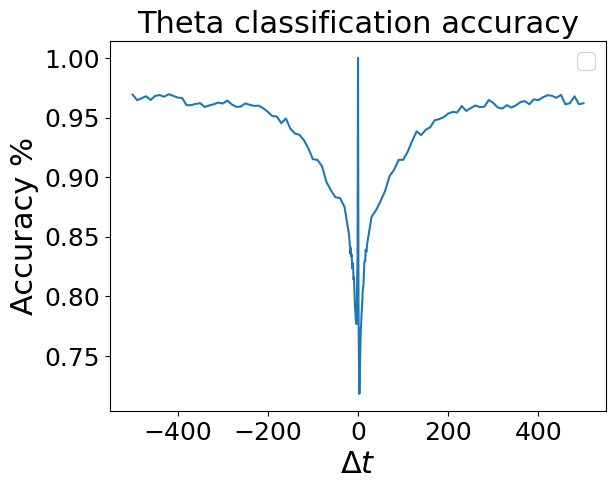

In [150]:
plt.figure(1)
plt.title("Theta classification accuracy")
plt.plot(dt_list[:], accuracy_list[:])
#plt.plot(future_list, np.array(RMSE_ridge), label="Ridge")
#plt.plot(future_list, np.array(naive), label="Naive")
#plt.plot(future_list, np.array(rmse_kernel), label="Kernel")
plt.legend()
plt.ylabel("Accuracy %")
plt.xlabel(r"$\Delta t$")
plt.show()

# Coefficient values - Single Neuron Decoding

In [44]:
folder_path = 'FelixData/'
dir_scalar = folder_path + "scalars_14336_0.csv"
dir_hstates = folder_path + "hstates_14336_0.csv"

In [45]:
def merge_files(file_path, file_path_scalar):
    # Reading the CSV files
    df_scalar = pd.read_csv(file_path_scalar, low_memory=False)

    df_scalar = df_scalar[df_scalar['# action'] != '# action']

    df = pd.read_csv(file_path, header=None, nrows=len(df_scalar))

    # Renaming the columns as "Node i"
    df.columns = [f"Node {i}" for i in range(1, df.shape[1] + 1)]
    
    df_scalar = df_scalar[df_scalar['player_position_x'] != 'player_position_x']
    merged_df = pd.concat([df_scalar.reset_index(drop=True), df.reset_index(drop=True)], axis=1)

    return merged_df

df = merge_files(dir_hstates, dir_scalar)
#episode_count = df['episode_id'].value_counts().sort_index()
#episode_count_sorted = episode_count.sort_values(ascending=False)
#print(episode_count_sorted)
most_common_episode_id = df['episode_id'].mode()[0]
episode_df = df[df['episode_id'] == most_common_episode_id]
episode_df['player_position_x'] = episode_df['player_position_x'].str.split('.').str[0].astype(int)
episode_df['player_position_y'] = episode_df['player_position_y'].str.split('.').str[0].astype(int)
episode_df['delta_x'] = episode_df['delta_x'].str.split('.').str[0].astype(int)
episode_df['delta_y'] = episode_df['delta_y'].str.split('.').str[0].astype(int)

In [46]:
def remove_rows(steps, df_merged):
    # Remove rows with NaN values resulting from shift
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    #print(df_merged['delta_X'].unique())
    return df_merged


In [47]:
def create_test(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['delta_y', 'delta_y']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 


    
    return  X_test, y_test
X_test, y_test = create_test(episode_df)

In [27]:
def get_data(path):
    folder_path = 'FelixData/'
    dir_scalar = folder_path + f"scalars_{path}.csv"
    dir_hstates = folder_path + f"hstates_{path}.csv"

    df = merge_files(dir_hstates, dir_scalar)
    #episode_count = df['episode_id'].value_counts().sort_index()
    #episode_count_sorted = episode_count.sort_values(ascending=False)
    #print(episode_count_sorted)
    most_common_episode_id = df['episode_id'].mode()[0]
    episode_df = df[df['episode_id'] == most_common_episode_id]
    episode_df['player_position_x'] = episode_df['player_position_x'].str.split('.').str[0].astype(int)
    episode_df['player_position_y'] = episode_df['player_position_y'].str.split('.').str[0].astype(int)
    episode_df['delta_x'] = episode_df['delta_x'].str.split('.').str[0].astype(int)
    episode_df['delta_y'] = episode_df['delta_y'].str.split('.').str[0].astype(int)
    X_test, y_test = create_test(episode_df)
    return X_test

X_test_full_PI = get_data("14336_0")
X_test_full_nPI = get_data("14336_0_nPI")
X_test_sparse_PI = get_data("29696_0")
X_test_sparse_nPI = get_data("43008_0")

X_test1 = get_data("40960_0_sparse_PI")
X_test2 = get_data("43008_0_sparse_PI")
X_test3 = get_data("45056_0_sparse_PI")

### short one for 13 episodes together

945.9855874353792
961.765491755873
849.4346947619741
753.985799806902
640.9066576462147
449.4425070450516
447.6084731045089
447.7586263604201
450.06454327656166
448.2039181267084
450.0060172379558
449.98103349593765
449.3564316254386
450.4855118924366
687.4518023008436
877.3798879474344
987.3743760528308
1095.0971254015642
1193.5757037049773


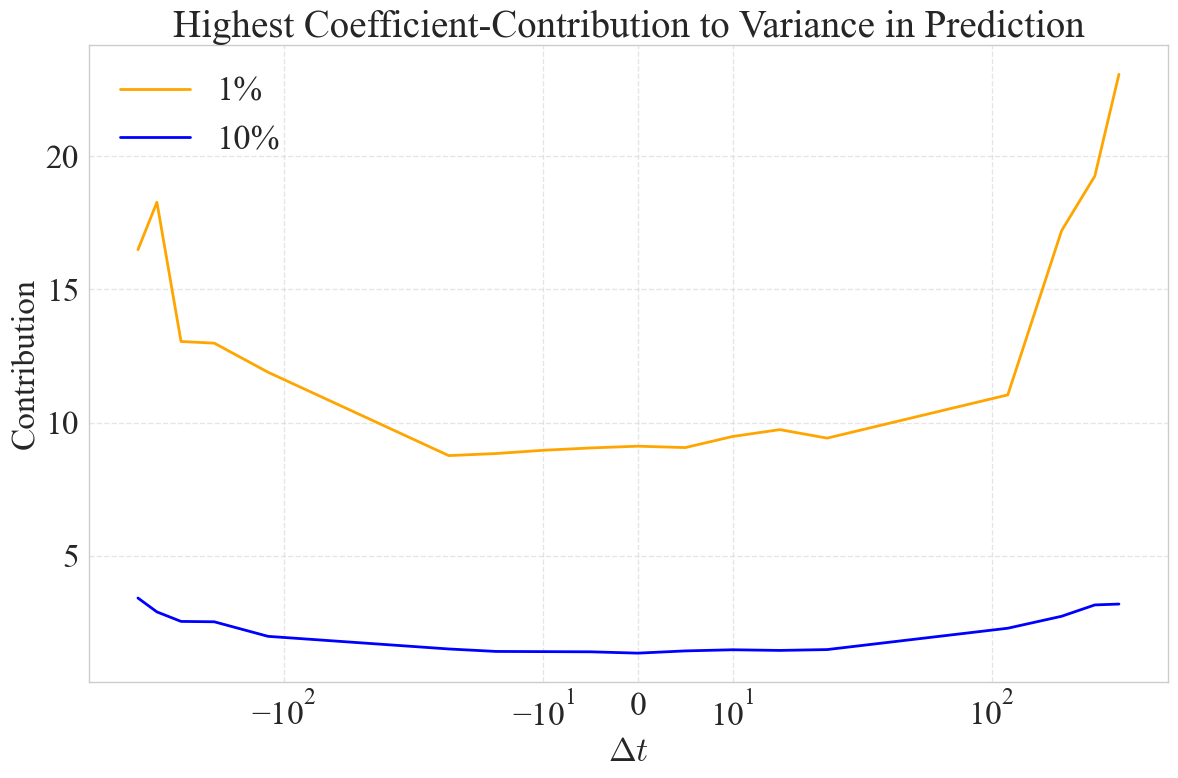

In [105]:
std_values_13 = np.std(X_test_13_episodes, axis=0)
# Load the stored data
with open('output/data_40k_13_520_a_spi_ci.pkl', 'rb') as f:
    data_loaded_13 = pickle.load(f)
all_data_13 = data_loaded_13['all_data']
contribution_list_13 = []
for model_list in all_data_13:
    #print(np.max(model_list[0].coef_))
    contribution_list_13.append(model_list[0].coef_ *  np.array([std_values_13, std_values_13]))

#for i in range(len(contribution_list_13)):
#    print(np.max(contribution_list_13[i]))
#print(contribution_list_13)

#print(contribution_list_13)

#print(dt_list[9])

start = 0 # 98 is zero
dt = 1
end = start + len(dt_list)
new_dt_list = dt_list[::dt]
bar_size = 0.5

#for i in range(len(new_dt_list)):
 #   print(np.sort(contribution_list_13[1])[::-1][:5])


# Slice the contribution lists into three parts
#slices = [(start + i*dt, start + (i+1)*dt) for i in range(len(new_dt_list)) ]
#print(slices)

# Create lists to hold the sliced magnitude lists
#magnitude_lists = []

#for s in slices:
#    magnitude_lists.append(np.abs(contribution_list_13[s[0]:s[1], :, :]).flatten())

magnitude_lists = []
for i in range(len(contribution_list_13)):
    magnitude_lists.append(contribution_list_13[i].flatten())
    #print(np.max(contribution_list_13[i].flatten()))


# Normalize each list
#for i in range(len(new_dt_list)):
#    magnitude_lists[i] = magnitude_lists[i] / (np.sum(magnitude_lists[i]) * 0.0001)



# Calculate the top X% contributions
def top_percent_contributions(magnitude_list, percent):
    return np.sort(magnitude_list)[-int(len(magnitude_list) * percent / 100):]  # Top X%


for i in range(len(magnitude_lists)):
    print(np.sum(top_percent_contributions(magnitude_lists[i], 10)[::-1]))

# Function to calculate the 95% confidence interval
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)  # Standard error of the mean
    margin = 1.96 * std_err  # Z-score for 95% CI
    return margin

# Define the percentages to show
percentages = [30, 10, 1]

listlist = []
listlist10 = []

for j in range(len(magnitude_lists)):
    top_1 = top_percent_contributions(magnitude_lists[j], 1)
    top_10 = top_percent_contributions(magnitude_lists[j], 10)
    listlist.append(top_1)
    listlist10.append(top_10)

"""
for j, (magnitude_list) in enumerate(zip(magnitude_lists)):
    for i, percent in enumerate(percentages):
        # Extract top X% contributions
        top_PI = top_percent_contributions(magnitude_list, percent)

        # Get means and 95% CIs for plotting
        mean_PI, ci_PI = np.mean(top_PI), confidence_interval(top_PI)

        if i == 2:
            listlist.append([mean_PI])
        if i == 1: 
            listlist10.append([mean_PI])

"""


listlist = np.array(listlist)
listlist10 = np.array(listlist10)
import matplotlib.pyplot as plt

# Create a single plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the first line
ax.plot(new_dt_list[:-1], listlist[:, 0][:-1], label="1%", color='orange', linewidth=2)
# Plot the second line
ax.plot(new_dt_list[:-1], listlist10[:, 0][:-1], label="10%", color='blue', linewidth=2)

# Configure the axes
ax.set_xscale('symlog', linthresh=24)
ax.set_xlabel(r'$\Delta t$', fontsize=24)
ax.set_ylabel("Contribution", fontsize=24)
ax.set_title("Highest Coefficient-Contribution to Variance in Prediction", fontsize=28)
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=24)
ax.legend(loc='upper left', fontsize=25)

# Adjusting layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


(3, 512)
(2, 512)
(2, 512)
{450, 423, 200, 140, 365, 333, 303, 399, 442, 430, 13, 25, 215, 121, 122, 156, 414}


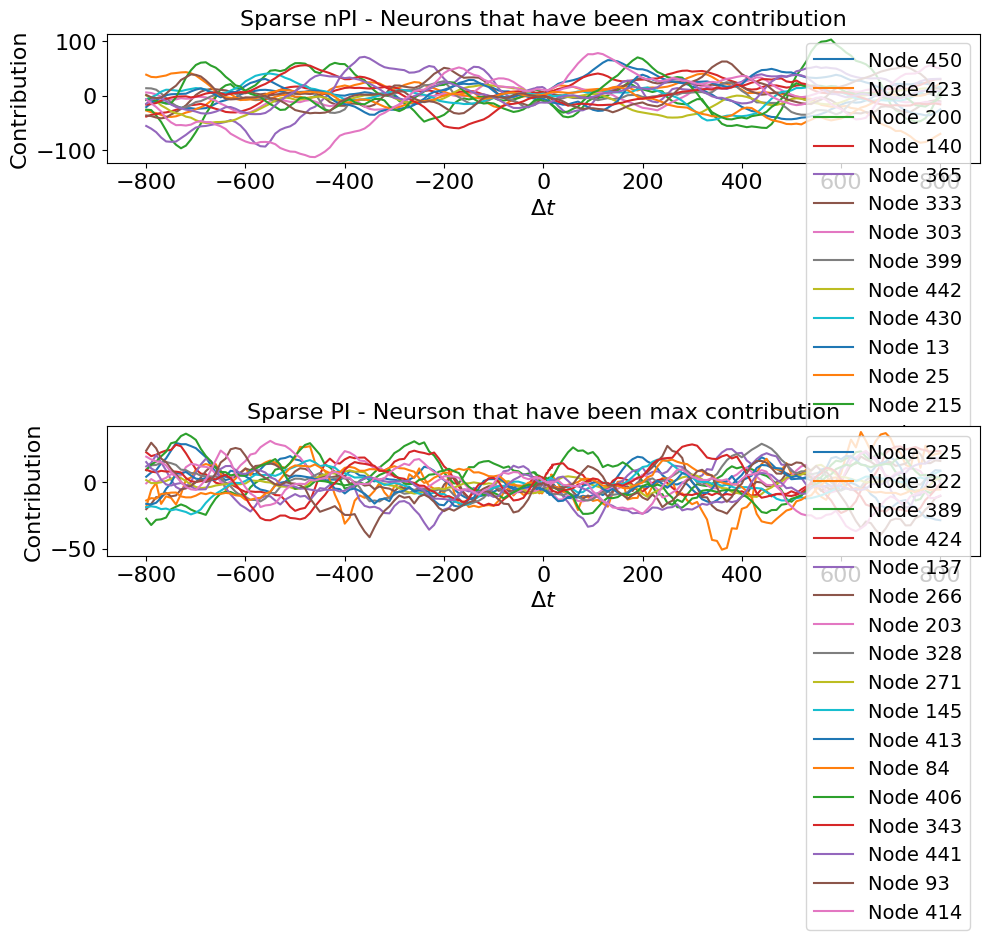

In [30]:
import pickle




max_abs_values = np.max(np.abs(X_test_full_PI), axis=0)
std_values = np.std(X_test_full_PI, axis=0)
abs_mean_values = np.mean(np.abs(X_test_full_PI), axis=0)
#print(abs_mean_values[:10])
#print(abs_mean_values[96])
#print(std_values[96])
range_values = abs_mean_values*std_values
#print(range_values[:10])
std_values_full_PI = np.std(X_test_full_PI, axis=0)
std_values_full_nPI = np.std(X_test_full_nPI, axis=0)
std_values_sparse_PI = np.std(X_test_sparse_PI, axis=0)
std_array = np.array([np.std(X_test1, axis=0),np.std(X_test2, axis=0),np.std(X_test3, axis=0)])
print(std_array.shape)
std_values_sparse_nPI = np.mean(std_array, axis=0)
#std_values_sparse_nPI = np.std(X_test_sparse_nPI, axis=0)




# Load the stored data
with open('output/data_14336_800_a_PI.pkl', 'rb') as f:
    data_loaded_PI = pickle.load(f)

with open('output/data_14336_800_a_nPI.pkl', 'rb') as f:
    data_loaded_nPI = pickle.load(f)

with open('output/data_29696_800_a_sparse_PI.pkl', 'rb') as f:
    data_loaded_sparse_PI = pickle.load(f)

#with open('output/data_43008_800_a_sparse_nPI.pkl', 'rb') as f:
with open('output/data_40k_trio_800_a_sparse_PI.pkl', 'rb') as f:
    data_loaded_sparse_nPI = pickle.load(f)

# Retrieve the 'all_data' which contains the models
all_data_PI = data_loaded_PI['all_data']
all_data_nPI = data_loaded_nPI['all_data']
all_data_sparse_PI = data_loaded_sparse_PI['all_data']
all_data_sparse_nPI = data_loaded_sparse_nPI['all_data']

# Iterate over all model1 instances in all_data and print model1.coeffs_
coeffs_list = []
intercept_list = []
contribution_list_PI = []
contribution_list_nPI = []
contribution_list_sparse_PI = []
contribution_list_sparse_nPI = []
for model_list in all_data_PI:
    model1 = model_list[2]  # Assuming model1 is the first model in each list
    coeff = model1.coef_
    coeffs_list.append(coeff)
    contribution_list_PI.append(coeff * np.array([std_values_full_PI, std_values_full_PI]))
    intercept_list.append(np.mean(model1.intercept_))

for model_list in all_data_nPI:
    contribution_list_nPI.append(model_list[2].coef_ *  np.array([std_values_full_nPI, std_values_full_nPI]))

for model_list in all_data_sparse_PI:
    contribution_list_sparse_PI.append(model_list[2].coef_ *  np.array([std_values_sparse_PI, std_values_sparse_PI]))

for model_list in all_data_sparse_nPI:
    contribution_list_sparse_nPI.append(model_list[2].coef_ *  np.array([std_values_sparse_nPI, std_values_sparse_nPI]))

coeffs_list = np.array(coeffs_list)
contribution_list_PI = np.array(contribution_list_PI)
contribution_list_nPI = np.array(contribution_list_nPI)
contribution_list_sparse_PI = np.array(contribution_list_sparse_PI)
contribution_list_sparse_nPI = np.array(contribution_list_sparse_nPI)
print(coeffs_list[118,:,:].shape) # dt = 20
print(contribution_list_nPI[118,:,:].shape)
#plt.figure(1)
#plt.plot(dt_list,coeffs_list)
#plt.plot(dt_list,intercept_list, label = "intercept")
#plt.legend()
#plt.show()
#print(intercept_list)
plt.rcParams.update({
    'axes.labelsize': 16,   # Size of x and y labels
    'xtick.labelsize': 16,  # Size of x-tick labels
    'ytick.labelsize': 16,  # Size of y-tick labels
    'legend.fontsize': 14,  # Size of legend font
    'axes.titlesize': 16    # Size of title
})
idx_list = []
idx_list1 = []
argmaxes = []
argmaxes1 = []
for i in range(len(dt_list)):
    argmaxes.append(np.argmax(np.abs(contribution_list_sparse_nPI[i][0,:])))
    argmaxes1.append(np.argmax(np.abs(contribution_list_sparse_PI[i][0,:])))
    #print(np.max(np.abs(contribution_list[i][0,:])))
    #print(np.argmax(np.abs(contribution_list[i][0,:])))

for i in range(len(dt_list)):
    l = []
    j = []
    for idx in list(set(argmaxes)):
        l.append(contribution_list_sparse_nPI[i][0,idx])
    for idx in list(set(argmaxes1)):
        j.append(contribution_list_sparse_PI[i][0,idx])
    idx_list.append(l)
    idx_list1.append(j)

print(set(argmaxes))
#print(contribution_list_PI)

string_list = [f"Node {i}" for i in list(set(argmaxes))]
string_list1 = [f"Node {i}" for i in list(set(argmaxes1))]

# Create a figure and define subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))  # 2 rows, 1 column for vertical stacking

# Plot idx_list on the first subplot
axs[0].plot(dt_list, np.array(idx_list), label=string_list)
axs[0].set_xlabel(r'$\Delta t$')
axs[0].set_ylabel('Contribution')
axs[0].set_title("Sparse nPI - Neurons that have been max contribution")
axs[0].legend()

# Plot idx_list1 on the second subplot
axs[1].plot(dt_list, np.array(idx_list1), label=string_list1)
axs[1].set_xlabel(r'$\Delta t$')
axs[1].set_ylabel('Contribution')
axs[1].set_title("Sparse PI - Neurson that have been max contribution")
axs[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

30


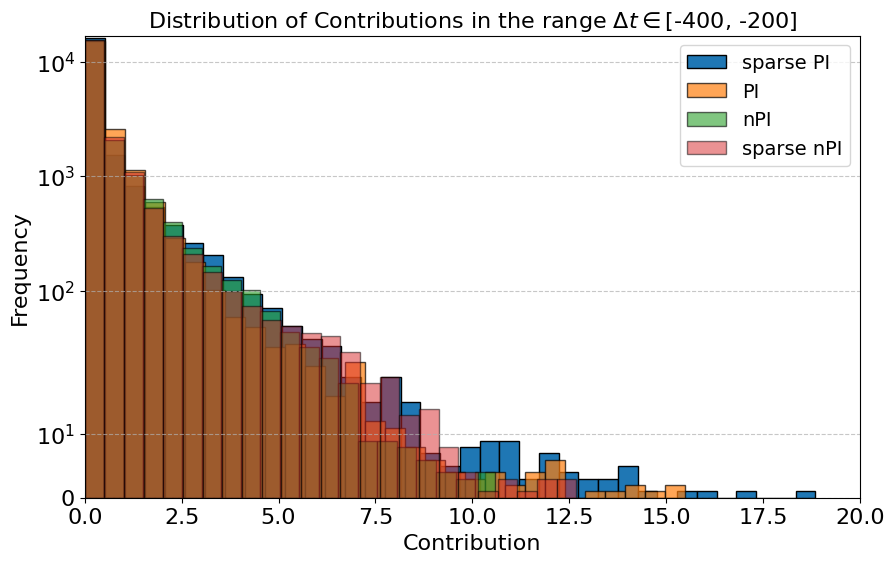

5213
Sparse PI: The sum of contributions: 10000. The maximum contribution: 18.857042133509047
nPI: The sum of contributions: 10000. The maximum contribution: 10.574792772125766
PI: The sum of contributions: 10000. The maximum contribution: 15.482462109120782
Sparse nPI: The sum of contributions: 10000. The maximum contribution: 12.689047846589986


In [31]:
# Flatten the matrix to compute the magnitude
start = 40
end = 60
bar_size = 0.5
magnitude_list = np.abs(contribution_list_PI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list[start:end,:,:]))
magnitude_list1 = np.abs(contribution_list_nPI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list_nPI[start:end,:,:]))
magnitude_list2 = np.abs(contribution_list_sparse_PI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list_sparse[start:end,:,:]))
magnitude_list3 = np.abs(contribution_list_sparse_nPI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list_sparse[start:end,:,:]))

#print(np.sum(magnitude_list))
magnitude_list = magnitude_list/(np.sum(magnitude_list)*0.0001)
magnitude_list1 = magnitude_list1/(np.sum(magnitude_list1)*0.0001)
magnitude_list2 = magnitude_list2/(np.sum(magnitude_list2)*0.0001)
magnitude_list3 = magnitude_list3/(np.sum(magnitude_list3)*0.0001)
#print(np.sum(magnitude_list))

num_bins1 = int((max(magnitude_list) - min(magnitude_list))/bar_size)
num_bins2 = int((max(magnitude_list1) - min(magnitude_list1))/bar_size)
num_bins3 = int((max(magnitude_list2) - min(magnitude_list2))/bar_size)
num_bins4 = int((max(magnitude_list3) - min(magnitude_list3))/bar_size)
print(num_bins1)


# Plotting the histogram
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.hist(magnitude_list2, bins=num_bins3, edgecolor='black', label="sparse PI", alpha=1)
ax.hist(magnitude_list, bins=num_bins1, edgecolor='black', label="PI", alpha=0.7)
ax.hist(magnitude_list1, bins=num_bins2, edgecolor='black', label="nPI", alpha=0.6)
ax.hist(magnitude_list3, bins=num_bins4, edgecolor='black', label="sparse nPI", alpha=0.5)

plt.xlabel('Contribution')
plt.ylabel('Frequency')
ax.legend()
plt.title(rf'Distribution of Contributions in the range $\Delta t \in $[{dt_list[start]}, {dt_list[end]}]')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 20)
ax.set_yscale('symlog', linthresh=20)
#plt.ylim(0, 150)
plt.show()
print(np.argmax(magnitude_list2))
print(f'Sparse PI: The sum of contributions: {round(sum(magnitude_list2))}. The maximum contribution: {np.max(magnitude_list2)}')
print(f'nPI: The sum of contributions: {round(sum(magnitude_list1))}. The maximum contribution: {np.max(magnitude_list1)}')
print(f'PI: The sum of contributions: {round(sum(magnitude_list))}. The maximum contribution: {np.max(magnitude_list)}')
print(f'Sparse nPI: The sum of contributions: {round(sum(magnitude_list3))}. The maximum contribution: {np.max(magnitude_list3)}')

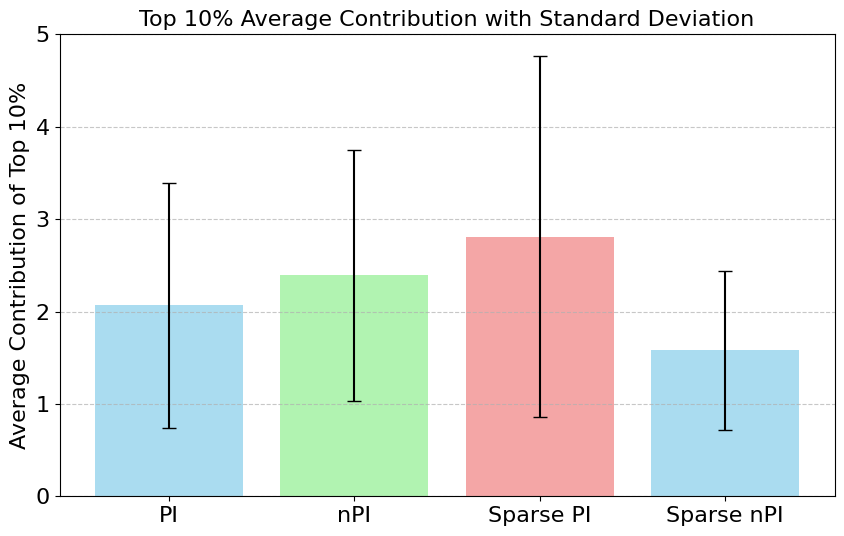

In [101]:
# Calculate the top 10% contributions
def top_10_percent_stats(magnitude_list):
    top_10_percent = np.sort(magnitude_list)[-int(len(magnitude_list) * 0.1):]  # Top 10%
    mean_value = np.mean(top_10_percent)
    std_value = np.std(top_10_percent)
    return mean_value, std_value

mean_PI, std_PI = top_10_percent_stats(magnitude_list)
mean_nPI, std_nPI = top_10_percent_stats(magnitude_list1)
mean_sparse_PI, std_sparse_PI = top_10_percent_stats(magnitude_list2)
mean_sparse_nPI, std_sparse_nPI = top_10_percent_stats(magnitude_list3)

# Plotting the bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 6))
x_labels = ['PI', 'nPI', 'Sparse PI', 'Sparse nPI']
means = [mean_PI, mean_nPI, mean_sparse_PI, mean_sparse_nPI]
std_devs = [std_PI, std_nPI, std_sparse_PI, std_sparse_nPI]

ax.bar(x_labels, means, yerr=std_devs, capsize=5, color=['skyblue', 'lightgreen', 'lightcoral'], alpha=0.7)
ax.set_ylabel('Average Contribution of Top 10%')
ax.set_title('Top 10% Average Contribution with Standard Deviation')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

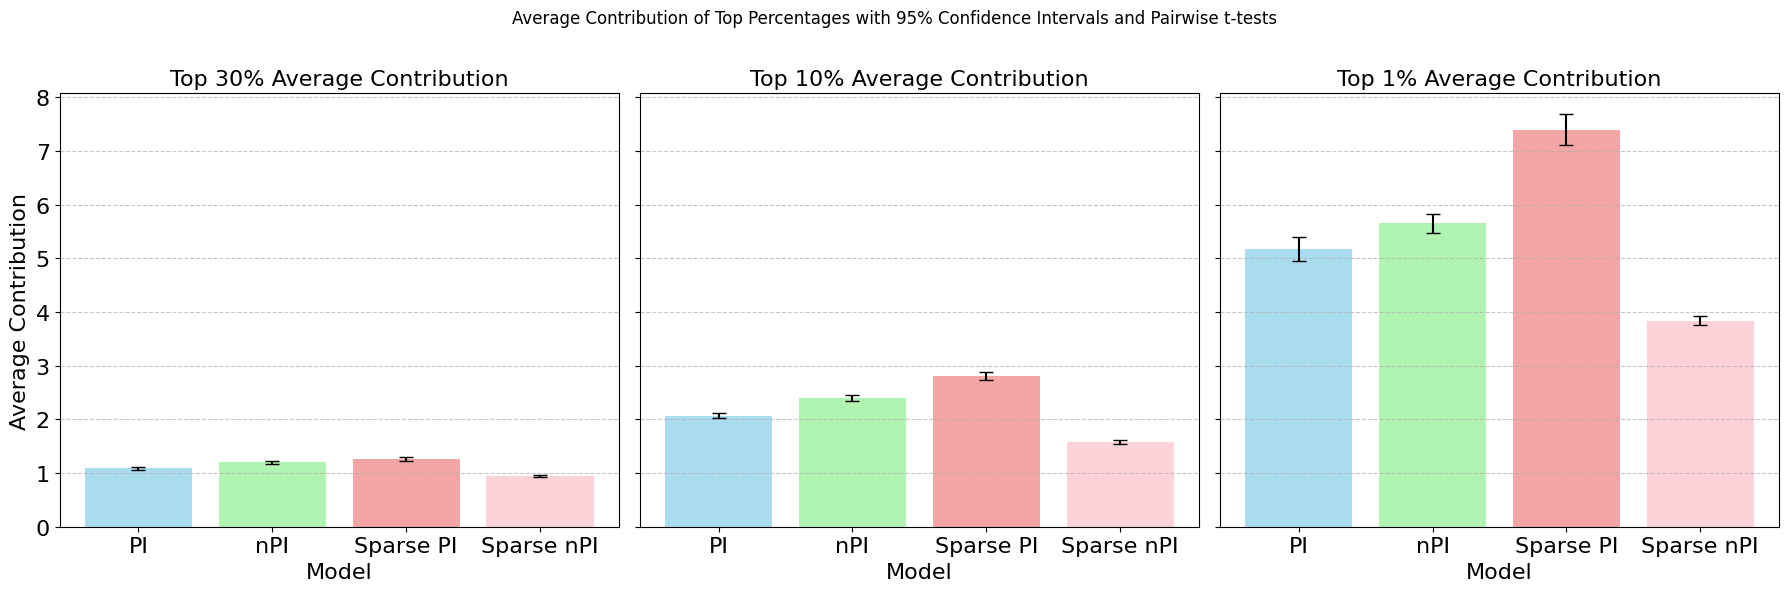

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Calculate the top X% contributions
def top_percent_contributions(magnitude_list, percent):
    return np.sort(magnitude_list)[-int(len(magnitude_list) * percent / 100):]  # Top X%

# Function to calculate the 95% confidence interval
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)  # Standard error of the mean
    margin = 1.96 * std_err  # Z-score for 95% CI
    return margin


# Define the percentages to show
percentages = [30, 10, 1]

# Create subplots
fig, axes = plt.subplots(1, len(percentages), figsize=(18, 6), sharey=True)

for i, percent in enumerate(percentages):
    # Extract top X% contributions
    top_PI = top_percent_contributions(magnitude_list, percent)
    top_nPI = top_percent_contributions(magnitude_list1, percent)
    top_sparse_PI = top_percent_contributions(magnitude_list2, percent)
    top_sparse_nPI = top_percent_contributions(magnitude_list3, percent)

    # Perform t-tests
    #ttest_nPI_PI = ttest_ind(top_nPI, top_PI)
    #ttest_nPI_sparse_PI = ttest_ind(top_nPI, top_sparse_PI)

    # Get means and 95% CIs for plotting
    mean_PI, ci_PI = np.mean(top_PI), confidence_interval(top_PI)
    mean_nPI, ci_nPI = np.mean(top_nPI), confidence_interval(top_nPI)
    mean_sparse_PI, ci_sparse_PI = np.mean(top_sparse_PI), confidence_interval(top_sparse_PI)
    mean_sparse_nPI, ci_sparse_nPI = np.mean(top_sparse_nPI), confidence_interval(top_sparse_nPI)

    # Plotting the bar plot with 95% CIs as error bars for the current subplot
    ax = axes[i]
    x_labels = ['PI', 'nPI', 'Sparse PI', 'Sparse nPI']
    means = [mean_PI, mean_nPI, mean_sparse_PI, mean_sparse_nPI]
    ci_values = [ci_PI, ci_nPI, ci_sparse_PI, ci_sparse_nPI]

    ax.bar(x_labels, means, yerr=ci_values, capsize=5, color=['skyblue', 'lightgreen', 'lightcoral', 'pink'], alpha=0.7)
    ax.set_title(f'Top {percent}% Average Contribution')

    # Add t-test results as text
    #ax.text(0.5, max(means) + max(ci_values), f'nPI vs PI p={ttest_nPI_PI.pvalue:.3f}', ha='center', fontsize=10, color='black')
    #ax.text(1.5, max(means) + max(ci_values), f'nPI vs Sparse p={ttest_nPI_sparse_PI.pvalue:.3f}', ha='center', fontsize=10, color='black')

    ax.set_xlabel('Model')
    if i == 0:
        ax.set_ylabel('Average Contribution')

    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Average Contribution of Top Percentages with 95% Confidence Intervals and Pairwise t-tests')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


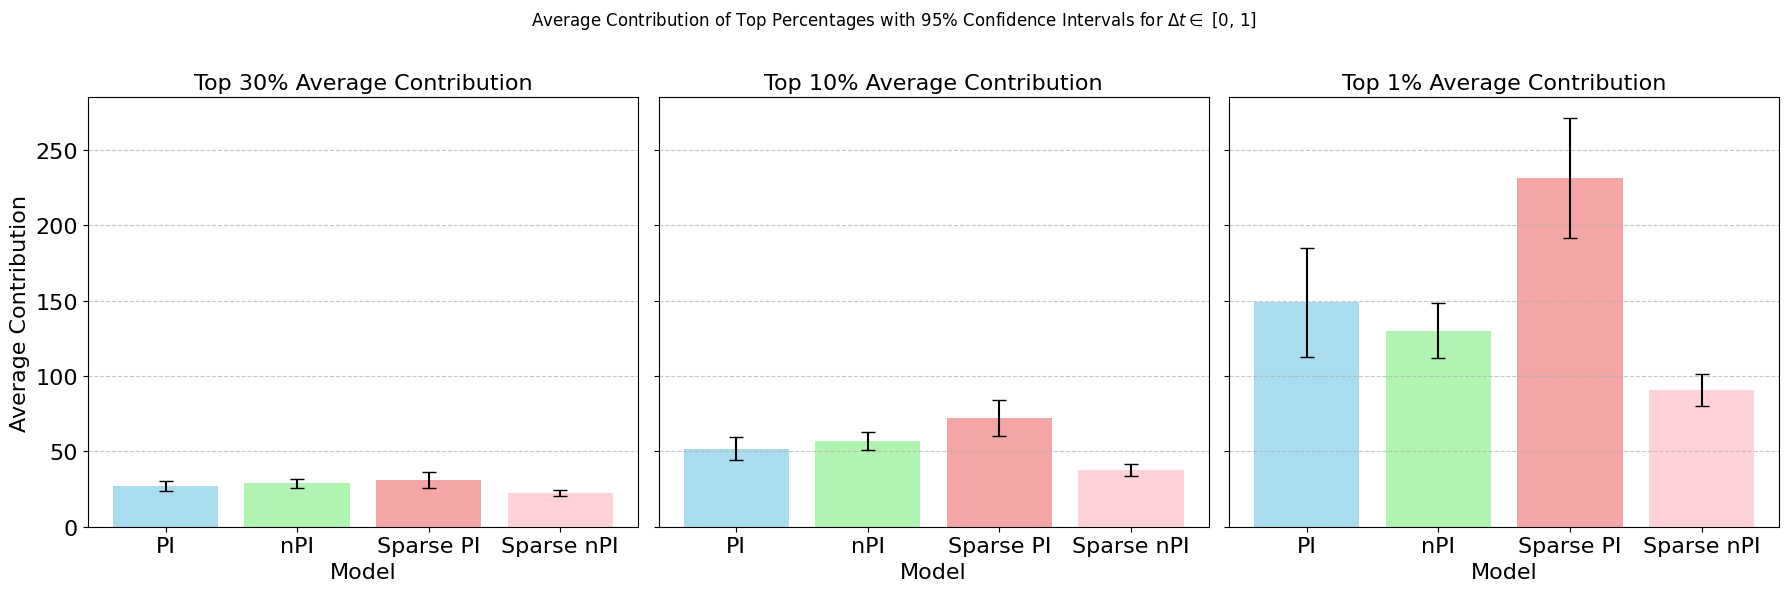

In [117]:
start = 98
end = 99
bar_size = 0.5
magnitude_list = np.abs(contribution_list_PI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list[start:end,:,:]))
magnitude_list1 = np.abs(contribution_list_nPI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list_nPI[start:end,:,:]))
magnitude_list2 = np.abs(contribution_list_sparse_PI[start:end,:,:]).flatten()#/np.sum(np.abs(contribution_list_sparse[start:end,:,:]))
magnitude_list3 = np.abs(contribution_list_sparse_nPI[start:end,:,:]).flatten()
#print(np.sum(magnitude_list))
magnitude_list = magnitude_list/(np.sum(magnitude_list)*0.0001)
magnitude_list1 = magnitude_list1/(np.sum(magnitude_list1)*0.0001)
magnitude_list2 = magnitude_list2/(np.sum(magnitude_list2)*0.0001)
magnitude_list3 = magnitude_list3/(np.sum(magnitude_list3)*0.0001)

#print(np.sum(magnitude_list))

# Calculate the top X% contributions
def top_percent_contributions(magnitude_list, percent):
    return np.sort(magnitude_list)[-int(len(magnitude_list) * percent / 100):]  # Top X%

# Function to calculate the 95% confidence interval
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)  # Standard error of the mean
    margin = 1.96 * std_err  # Z-score for 95% CI
    return margin


# Define the percentages to show
percentages = [30, 10, 1]

# Create subplots
fig, axes = plt.subplots(1, len(percentages), figsize=(18, 6), sharey=True)

for i, percent in enumerate(percentages):
    # Extract top X% contributions
    top_PI = top_percent_contributions(magnitude_list, percent)
    top_nPI = top_percent_contributions(magnitude_list1, percent)
    top_sparse_PI = top_percent_contributions(magnitude_list2, percent)
    top_sparse_nPI = top_percent_contributions(magnitude_list3, percent)

    # Perform t-tests
    #ttest_nPI_PI = ttest_ind(top_nPI, top_PI)
    #ttest_nPI_sparse_PI = ttest_ind(top_nPI, top_sparse_PI)

    # Get means and 95% CIs for plotting
    mean_PI, ci_PI = np.mean(top_PI), confidence_interval(top_PI)
    mean_nPI, ci_nPI = np.mean(top_nPI), confidence_interval(top_nPI)
    mean_sparse_PI, ci_sparse_PI = np.mean(top_sparse_PI), confidence_interval(top_sparse_PI)
    mean_sparse_nPI, ci_sparse_nPI = np.mean(top_sparse_nPI), confidence_interval(top_sparse_nPI)

    # Plotting the bar plot with 95% CIs as error bars for the current subplot
    ax = axes[i]
    x_labels = ['PI', 'nPI', 'Sparse PI', 'Sparse nPI']
    means = [mean_PI, mean_nPI, mean_sparse_PI, mean_sparse_nPI]
    ci_values = [ci_PI, ci_nPI, ci_sparse_PI, ci_sparse_nPI]

    ax.bar(x_labels, means, yerr=ci_values, capsize=5, color=['skyblue', 'lightgreen', 'lightcoral','pink'], alpha=0.7)
    ax.set_title(f'Top {percent}% Average Contribution')

    # Add t-test results as text
    #ax.text(0.5, max(means) + max(ci_values), f'nPI vs PI p={ttest_nPI_PI.pvalue:.3f}', ha='center', fontsize=10, color='black')
    #ax.text(1.5, max(means) + max(ci_values), f'nPI vs Sparse p={ttest_nPI_sparse_PI.pvalue:.3f}', ha='center', fontsize=10, color='black')

    ax.set_xlabel('Model')
    if i == 0:
        ax.set_ylabel('Average Contribution')

    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle(rf'Average Contribution of Top Percentages with 95% Confidence Intervals for $\Delta t \in$ [{dt_list[start]}, {dt_list[end]}] ')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

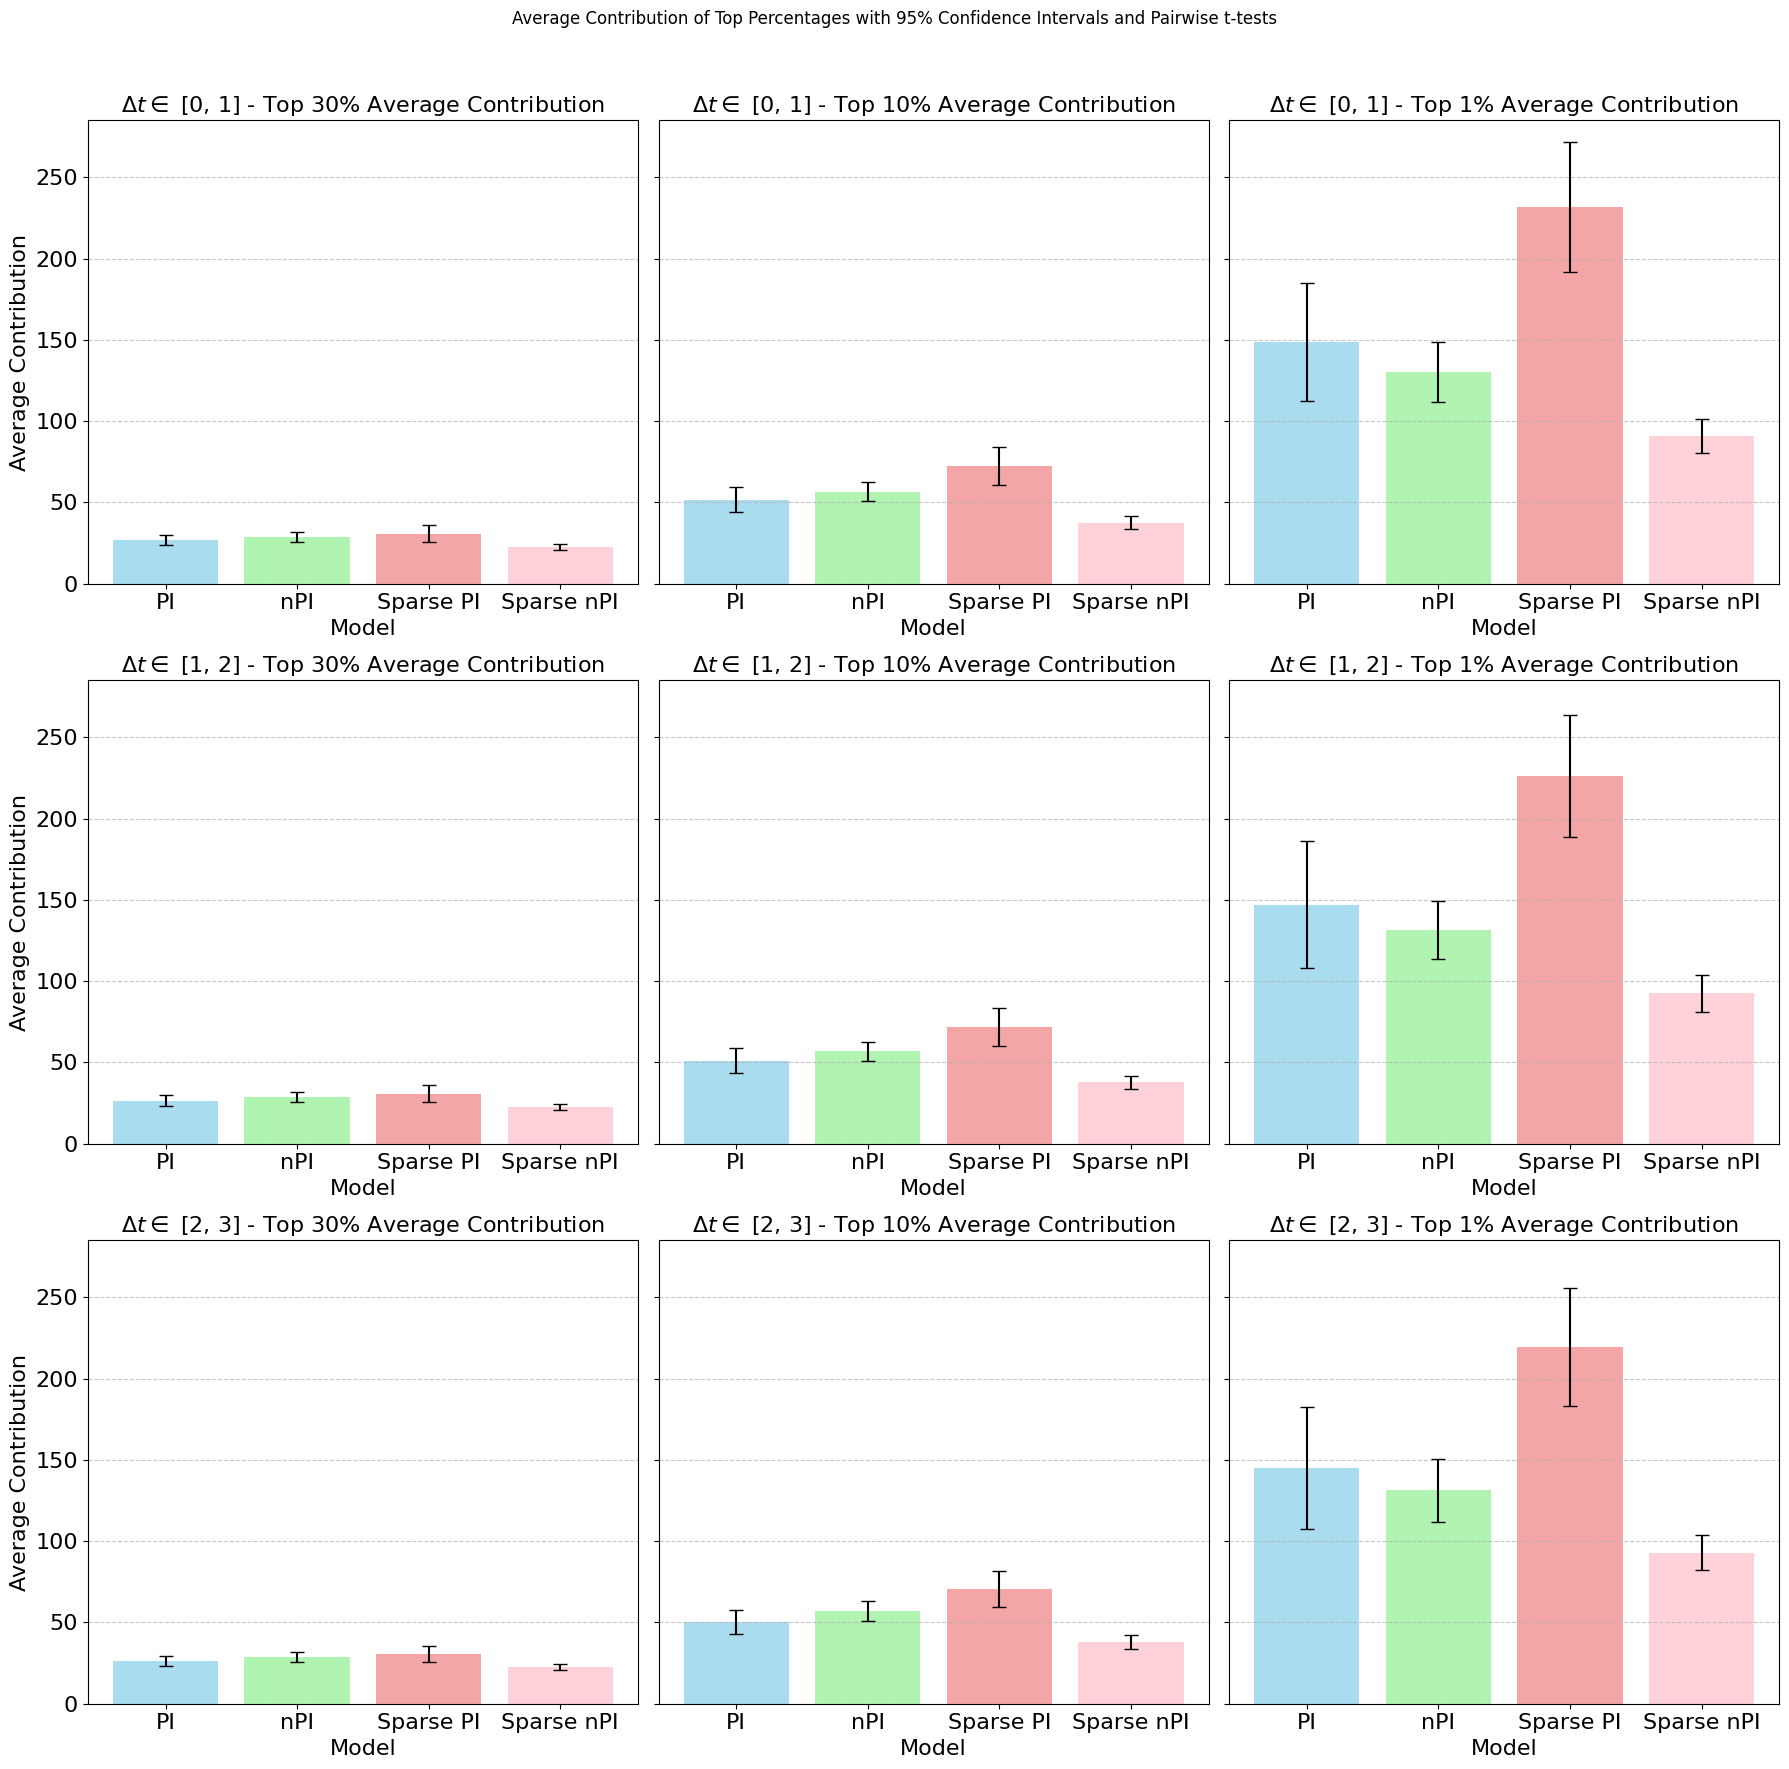

In [118]:
start = 98#138 # 98 is zero
dt = 1
end = start + dt*3
bar_size = 0.5


# Slice the contribution lists into three parts
slices = [(start, start + dt), (start + dt, start + 2*dt), (start + 2*dt, end)]

# Create lists to hold the sliced magnitude lists
magnitude_lists = []
magnitude_lists1 = []
magnitude_lists2 = []
magnitude_lists3 = []

for s in slices:
    magnitude_lists.append(np.abs(contribution_list_PI[s[0]:s[1], :, :]).flatten())
    magnitude_lists1.append(np.abs(contribution_list_nPI[s[0]:s[1], :, :]).flatten())
    magnitude_lists2.append(np.abs(contribution_list_sparse_PI[s[0]:s[1], :, :]).flatten())
    magnitude_lists3.append(np.abs(contribution_list_sparse_nPI[s[0]:s[1], :, :]).flatten())

# Normalize each list
for i in range(3):
    magnitude_lists[i] = magnitude_lists[i] / (np.sum(magnitude_lists[i]) * 0.0001)
    magnitude_lists1[i] = magnitude_lists1[i] / (np.sum(magnitude_lists1[i]) * 0.0001)
    magnitude_lists2[i] = magnitude_lists2[i] / (np.sum(magnitude_lists2[i]) * 0.0001)
    magnitude_lists3[i] = magnitude_lists3[i] / (np.sum(magnitude_lists3[i]) * 0.0001)

# Calculate the top X% contributions
def top_percent_contributions(magnitude_list, percent):
    return np.sort(magnitude_list)[-int(len(magnitude_list) * percent / 100):]  # Top X%

# Function to calculate the 95% confidence interval
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)  # Standard error of the mean
    margin = 1.96 * std_err  # Z-score for 95% CI
    return margin

# Define the percentages to show
percentages = [30, 10, 1]

# Create subplots (3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 18), sharey=True)

for j, (magnitude_list, magnitude_list1, magnitude_list2, magnitude_list3) in enumerate(zip(magnitude_lists, magnitude_lists1, magnitude_lists2, magnitude_lists3)):
    for i, percent in enumerate(percentages):
        # Extract top X% contributions
        top_PI = top_percent_contributions(magnitude_list, percent)
        top_nPI = top_percent_contributions(magnitude_list1, percent)
        top_sparse_PI = top_percent_contributions(magnitude_list2, percent)
        top_sparse_nPI = top_percent_contributions(magnitude_list3, percent)

        # Perform t-tests
        #ttest_nPI_PI = ttest_ind(top_nPI, top_PI)
        #ttest_nPI_sparse_PI = ttest_ind(top_nPI, top_sparse_PI)

        # Get means and 95% CIs for plotting
        mean_PI, ci_PI = np.mean(top_PI), confidence_interval(top_PI)
        mean_nPI, ci_nPI = np.mean(top_nPI), confidence_interval(top_nPI)
        mean_sparse_PI, ci_sparse_PI = np.mean(top_sparse_PI), confidence_interval(top_sparse_PI)
        mean_sparse_nPI, ci_sparse_nPI = np.mean(top_sparse_nPI), confidence_interval(top_sparse_nPI)

        # Plotting the bar plot with 95% CIs as error bars for the current subplot
        ax = axes[j, i]
        x_labels = ['PI', 'nPI', 'Sparse PI', 'Sparse nPI']
        means = [mean_PI, mean_nPI, mean_sparse_PI, mean_sparse_nPI]
        ci_values = [ci_PI, ci_nPI, ci_sparse_PI, ci_sparse_nPI]

        ax.bar(x_labels, means, yerr=ci_values, capsize=5, color=['skyblue', 'lightgreen', 'lightcoral', 'pink'], alpha=0.7)
        ax.set_title(rf'$\Delta t \in$ [{dt_list[slices[j][0]]}, {dt_list[slices[j][1]]}] - Top {percent}% Average Contribution')

        # Add t-test results as text
        #ax.text(0.5, max(means) + max(ci_values), f'nPI vs PI p={ttest_nPI_PI.pvalue:.3f}', ha='center', fontsize=10, color='black')
        #ax.text(1.5, max(means) + max(ci_values), f'nPI vs Sparse p={ttest_nPI_sparse_PI.pvalue:.3f}', ha='center', fontsize=10, color='black')

        ax.set_xlabel('Model')
        if i == 0:
            ax.set_ylabel('Average Contribution')

        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Average Contribution of Top Percentages with 95% Confidence Intervals and Pairwise t-tests')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


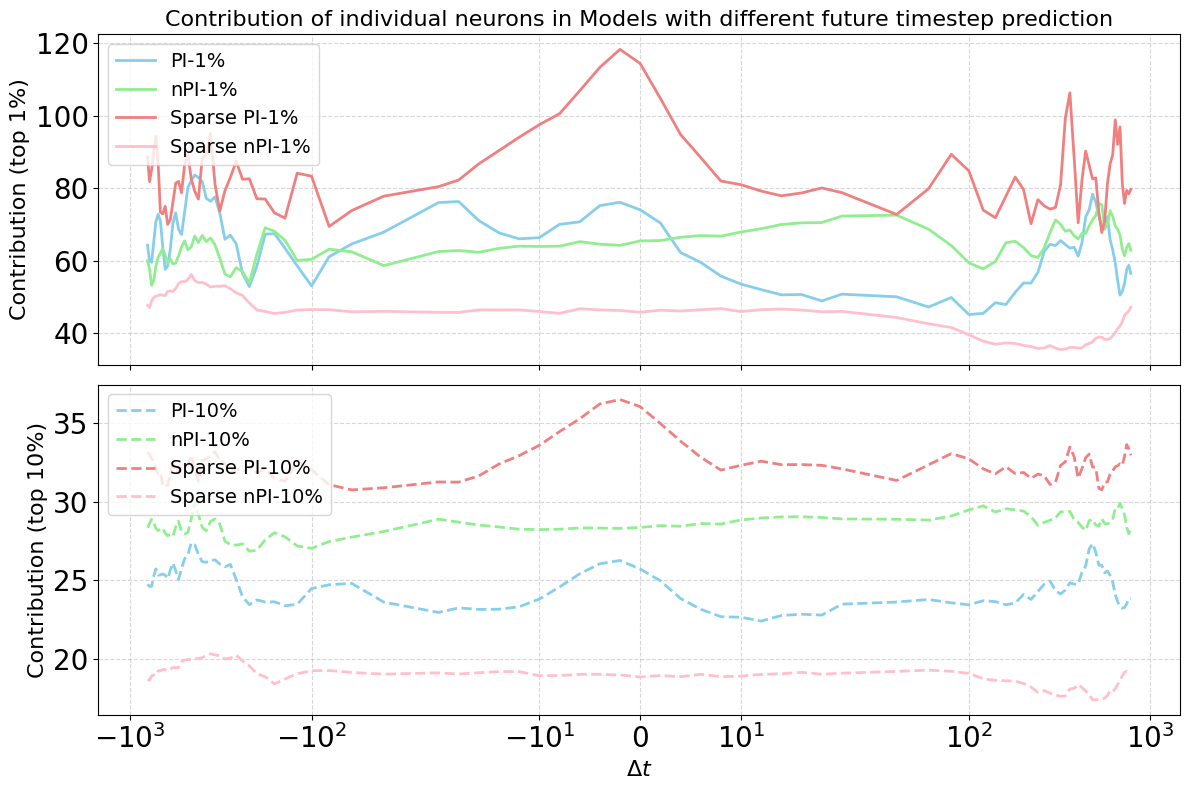

In [119]:
start = 0 # 98 is zero
dt = 2
end = start + len(dt_list)
new_dt_list = dt_list[::dt]
bar_size = 0.5


# Slice the contribution lists into three parts
slices = [(start + i*dt, start + (i+1)*dt) for i in range(len(new_dt_list)) ]

# Create lists to hold the sliced magnitude lists
magnitude_lists = []
magnitude_lists1 = []
magnitude_lists2 = []
magnitude_lists3 = []

for s in slices:
    magnitude_lists.append(np.abs(contribution_list_PI[s[0]:s[1], :, :]).flatten())
    magnitude_lists1.append(np.abs(contribution_list_nPI[s[0]:s[1], :, :]).flatten())
    magnitude_lists2.append(np.abs(contribution_list_sparse_PI[s[0]:s[1], :, :]).flatten())
    magnitude_lists3.append(np.abs(contribution_list_sparse_nPI[s[0]:s[1], :, :]).flatten())

# Normalize each list
for i in range(len(new_dt_list)):
    magnitude_lists[i] = magnitude_lists[i] / (np.sum(magnitude_lists[i]) * 0.0001)
    magnitude_lists1[i] = magnitude_lists1[i] / (np.sum(magnitude_lists1[i]) * 0.0001)
    magnitude_lists2[i] = magnitude_lists2[i] / (np.sum(magnitude_lists2[i]) * 0.0001)
    magnitude_lists3[i] = magnitude_lists3[i] / (np.sum(magnitude_lists3[i]) * 0.0001)

# Calculate the top X% contributions
def top_percent_contributions(magnitude_list, percent):
    return np.sort(magnitude_list)[-int(len(magnitude_list) * percent / 100):]  # Top X%

# Function to calculate the 95% confidence interval
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)  # Standard error of the mean
    margin = 1.96 * std_err  # Z-score for 95% CI
    return margin

# Define the percentages to show
percentages = [30, 10, 1]

listlist = []
listlist10 = []

for j, (magnitude_list, magnitude_list1, magnitude_list2, magnitude_list3) in enumerate(zip(magnitude_lists, magnitude_lists1, magnitude_lists2, magnitude_lists3)):
    for i, percent in enumerate(percentages):
        # Extract top X% contributions
        top_PI = top_percent_contributions(magnitude_list, percent)
        top_nPI = top_percent_contributions(magnitude_list1, percent)
        top_sparse_PI = top_percent_contributions(magnitude_list2, percent)
        top_sparse_nPI = top_percent_contributions(magnitude_list3, percent)

        # Perform t-tests
        #ttest_nPI_PI = ttest_ind(top_nPI, top_PI)
        #ttest_nPI_sparse_PI = ttest_ind(top_nPI, top_sparse_PI)

        # Get means and 95% CIs for plotting
        mean_PI, ci_PI = np.mean(top_PI), confidence_interval(top_PI)
        mean_nPI, ci_nPI = np.mean(top_nPI), confidence_interval(top_nPI)
        mean_sparse_PI, ci_sparse_PI = np.mean(top_sparse_PI), confidence_interval(top_sparse_PI)
        mean_sparse_nPI, ci_sparse_nPI = np.mean(top_sparse_nPI), confidence_interval(top_sparse_nPI)

        if i == 2:
            listlist.append([mean_PI, mean_nPI, mean_sparse_PI, mean_sparse_nPI])
        if i == 1: 
            listlist10.append([mean_PI, mean_nPI, mean_sparse_PI, mean_sparse_nPI])

       
listlist = np.array(listlist)
listlist10 = np.array(listlist10)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plotting the first subplot
axes[0].plot(new_dt_list[:-1], listlist[:, 0][:-1], label="PI-1%", color='skyblue', linewidth=2)
axes[0].plot(new_dt_list[:-1], listlist[:, 1][:-1], label="nPI-1%", color='lightgreen', linewidth=2)
axes[0].plot(new_dt_list[:-1], listlist[:, 2][:-1], label="Sparse PI-1%", color='lightcoral', linewidth=2)
axes[0].plot(new_dt_list[:-1], listlist[:, 3][:-1], label="Sparse nPI-1%", color='pink', linewidth=2)
axes[0].set_xscale('symlog', linthresh=20)
axes[0].set_ylabel("Contribution (top 1%)")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')
axes[0].tick_params(axis='both', which='major', labelsize=20)
axes[0].set_title("Contribution of individual neurons in Models with different future timestep prediction")

# Plotting the second subplot
axes[1].plot(new_dt_list[:-1], listlist10[:, 0][:-1], label="PI-10%", color='skyblue', linewidth=2, linestyle='--')
axes[1].plot(new_dt_list[:-1], listlist10[:, 1][:-1], label="nPI-10%", color='lightgreen', linewidth=2, linestyle='--')
axes[1].plot(new_dt_list[:-1], listlist10[:, 2][:-1], label="Sparse PI-10%", color='lightcoral', linewidth=2, linestyle='--')
axes[1].plot(new_dt_list[:-1], listlist10[:, 3][:-1], label="Sparse nPI-10%", color='pink', linewidth=2, linestyle='--')
axes[1].set_xscale('symlog', linthresh=20)
axes[1].set_xlabel(r'$\Delta t$')
axes[1].set_ylabel("Contribution (top 10%)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].tick_params(axis='both', which='major', labelsize=20)
axes[1].legend(loc='upper left')

# Adjusting layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Assuming X_train and y_train are already defined and the model is trained
# model1 = LinearRegression()
# model1.fit(X_train, y_train)

# Step 1: Calculate the mean and standard deviation of each feature (column) in X_train
mean_X_train = np.mean(X_test1, axis=0)
std_X_train = np.std(X_test1, axis=0)

# Step 2: Get the coefficients of the trained linear model
coefficients = mm1.coef_

# Step 3: Multiply the mean and standard deviation elementwise with the coefficients
# Elementwise multiplication for mean

mean_contributions = coefficients * np.array([mean_X_train, mean_X_train])
#print(mean_contributions)
# Elementwise multiplication for standard deviation
std_contributions = coefficients * np.array([std_X_train, std_X_train])
print(coefficients @ mean_X_train + mm1.intercept_)
#print(mean_X_train)
#print(mm1.predict(np.array([mean_X_train])))

print(np.mean(mm1.intercept_))
print(np.mean(coefficients))
print(np.mean(mean_X_train))
print(np.mean(mean_X_train)*np.mean(coefficients)+np.mean(mm1.intercept_))
#print(mean_contributions)

# Step 4: Analyze the contributions
# You can check which coefficients (dimensions) have the largest influence by looking at the absolute values
sorted_indices_mean = np.argsort(np.abs(mean_contributions))[::-1]  # Indices sorted by absolute mean contribution
sorted_indices_std = np.argsort(np.abs(std_contributions))[::-1]    # Indices sorted by absolute std contribution

print(sorted_indices_mean[:,:5])

# Step 5: Output the top features that contribute the most
print("Top 5 features contributing based on mean values:")
for i in range(5):
    print(f"Feature {i}: Mean contribution = {mean_contributions[:,i]}")

print("\nTop 5 features contributing based on standard deviation values:")
for idx in sorted_indices_std[:5]:
    print(f"Feature {idx}: Std contribution = {std_contributions[idx]}")


[ 2.82718188 -9.82286255]
63416065.94693577
-105305.2741973947
-0.04918955464210244
63421245.86647501
[[482 435 449 191 346]
 [482 191 486 245 435]]
Top 5 features contributing based on mean values:
Feature 0: Mean contribution = [-22.42558183  -3.47103907]
Feature 1: Mean contribution = [ 1.85511325 -1.63514291]
Feature 2: Mean contribution = [15846.99267377 45329.7390955 ]
Feature 3: Mean contribution = [ 1.36222    -5.34351702]
Feature 4: Mean contribution = [-336.273314    -65.28532505]

Top 5 features contributing based on standard deviation values:


IndexError: index 435 is out of bounds for axis 0 with size 2